<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/jiyoung/ADSD%2BCADICA_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 런타임 재연결용

In [ ]:
# =====================================================
# Runtime Setup (Run this after reconnecting)
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np
import os

PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

In [ ]:
##########################################################################

# Step 00. Data Preparation

In [ ]:
# =====================================================
# Step 00. Prepare ADSD Dataset
# =====================================================

import shutil
import zipfile
from pathlib import Path

zip_path = PROJECT_DIR / "Stenosis detection.zip"
extract_dir = PROJECT_DIR / "Stenosis detection_new"

# 이전 압축 해제 폴더 삭제
if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True)

print("Ready!")

Ready!


In [ ]:
# =====================================================
# Step 00. Extract ADSD Dataset
# =====================================================

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("압축 해제 완료!")

압축 해제 완료!


In [ ]:
# =====================================================
# Step 00. Verify ADSD Dataset
# =====================================================

ADSD_DIR = PROJECT_DIR / "Stenosis detection_new"
dataset_dir = ADSD_DIR / "dataset"

xml_count = len(list(dataset_dir.glob("*.xml")))
bmp_count = len(list(dataset_dir.glob("*.bmp")))

print("="*40)
print(f"XML : {xml_count}")
print(f"BMP : {bmp_count}")
print("="*40)

XML : 8325
BMP : 8325


# Step 1. Environment Setup

In [ ]:
# =====================================================
# Step 01. Environment Setup
# =====================================================

# Install
!pip install -q ultralytics

# Standard Library
import os
import shutil
import zipfile
import random
import warnings
from pathlib import Path

# Data Processing
import numpy as np
import pandas as pd

# Image Processing
import cv2
import xml.etree.ElementTree as ET

# Deep Learning
import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("=" * 50)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())
print("Ultralytics  :", YOLO)
print("=" * 50)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch      : 2.11.0+cu128
CUDA         : True
Ultralytics  : <class 'ultralytics.models.yolo.model.YOLO'>


# Step 2. Project Path


In [ ]:
# =====================================================
# Step 02. Project Path
# =====================================================

from pathlib import Path
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

# ADSD
ADSD_DIR = PROJECT_DIR / "Stenosis detection_new"

# CADICA
CADICA_DIR = PROJECT_DIR / "CADICA"

# Output
OUTPUT_DIR = PROJECT_DIR / "YOLO11_ADSD"

# Runs
RUNS_DIR = PROJECT_DIR / "runs"

print("=" * 50)
print(PROJECT_DIR)
print(ADSD_DIR)
print(CADICA_DIR)
print(OUTPUT_DIR)
print("=" * 50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/DL_project
/content/drive/MyDrive/DL_project/Stenosis detection_new
/content/drive/MyDrive/DL_project/CADICA
/content/drive/MyDrive/DL_project/YOLO11_ADSD


# Step 3. Dataset Inspection

In [ ]:
# 데이터셋 구조 확인
# =====================================================
# Step 03. Dataset Inspection
# =====================================================

print("=" * 60)
print("ADSD Folder")
print("=" * 60)

for item in sorted(ADSD_DIR.iterdir()):
    print(item.name)

ADSD Folder
dataset
test_labels.csv
timing_test.xlsx
timing_val.xlsx
train_labels.csv
video_test
video_val


In [ ]:
# XML/BMP 개수 확인
dataset_dir = ADSD_DIR / "dataset"

xml_files = list(dataset_dir.glob("*.xml"))
bmp_files = list(dataset_dir.glob("*.bmp"))

print("=" * 60)
print(f"XML : {len(xml_files)}")
print(f"BMP : {len(bmp_files)}")
print("=" * 60)

XML : 8325
BMP : 8325


In [ ]:
# Split CSV 확인


adsd_split = pd.read_csv(PROJECT_DIR / "adsd_patient_split.csv")
cadica_split = pd.read_csv(PROJECT_DIR / "common_split.csv")

print("=" * 60)
print("ADSD Split")
print("=" * 60)
display(adsd_split.head())

print()

print("=" * 60)
print("CADICA Split")
print("=" * 60)
display(cadica_split.head())

ADSD Split


,patient_id,n_images,split
0,14_002,53,train
1,14_003,44,train
2,14_006,113,train
3,14_007,374,train
4,14_010,82,test



CADICA Split


,patient_id,video_id,label,view,n_frames,has_groundtruth,split
0,p1,v2,lesion,LCA,56,True,train
1,p1,v3,lesion,LCA,44,True,train
2,p1,v10,lesion,LCA,56,True,train
3,p1,v11,lesion,LCA,44,True,train
4,p1,v1,non-lesion,LCA,55,False,train


In [ ]:
print("="*60)
print("ADSD")
print("="*60)
adsd_split.info()

print()

print("="*60)
print("CADICA")
print("="*60)
cadica_split.info()

ADSD
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  64 non-null     object
 1   n_images    64 non-null     int64 
 2   split       64 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB

CADICA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   patient_id       334 non-null    object
 1   video_id         334 non-null    object
 2   label            334 non-null    object
 3   view             334 non-null    object
 4   n_frames         334 non-null    int64 
 5   has_groundtruth  334 non-null    bool  
 6   split            334 non-null    object
dtypes: bool(1), int64(1), object(5)
memory usage: 16.1+ KB


In [ ]:
## xml 확인
xml_files = sorted((ADSD_DIR / "dataset").glob("*.xml"))

for f in xml_files[:20]:
    print(f.stem)

14_002_5_0016
14_002_5_0017
14_002_5_0018
14_002_5_0019
14_002_5_0020
14_002_5_0021
14_002_5_0022
14_002_5_0023
14_002_5_0024
14_002_5_0025
14_002_5_0026
14_002_5_0027
14_002_5_0028
14_002_5_0029
14_002_5_0030
14_002_5_0031
14_002_5_0032
14_002_5_0033
14_002_5_0034
14_002_5_0035


14     → Study(또는 Dataset Prefix)
002    → Patient ID
5      → Series/View
0016   → Frame 번호

parse_xml()

↓

convert_bbox_to_yolo()

↓

save_yolo_label()

↓

copy_image()

↓

build_adsd_dataset()

↓

verify_dataset()

XML 하나 선택
      │
      ▼
patient_id 확인
      │
      ▼
split.csv 조회
      │
      ▼
train / val / test 결정
      │
      ▼
XML → YOLO txt
      │
      ▼
Image 복사

# Step 4. Utility Functions
    4-1 parse_xml()
    4-2 convert_bbox_to_yolo()
    4-3 save_yolo_label()



In [ ]:
# XML 읽는 함수 XML Parser
# =====================================================
# XML Parser
# =====================================================

import xml.etree.ElementTree as ET


def parse_xml(xml_path):
    """
    Pascal VOC XML 파일을 읽어
    이미지 정보와 Bounding Box를 반환
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    objects = []

    for obj in root.findall("object"):

        name = obj.find("name").text

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        objects.append({
            "class": name,
            "bbox": (xmin, ymin, xmax, ymax)
        })

    return width, height, objects

XML

↓

Python Dictionary

↓

YOLO 좌표

↓

TXT 저장

In [ ]:
# bounding box를 yolo 형식으로 반환
# =====================================================
# VOC -> YOLO
# =====================================================

def convert_bbox_to_yolo(box, width, height):

    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / width
    y_center = ((ymin + ymax) / 2) / height

    box_width = (xmax - xmin) / width
    box_height = (ymax - ymin) / height

    return (
        x_center,
        y_center,
        box_width,
        box_height
    )

In [ ]:
# 검증
# XML 하나 선택
sample_xml = next((ADSD_DIR / "dataset").glob("*.xml"))

print(sample_xml)

/content/drive/MyDrive/DL_project/Stenosis detection_new/dataset/14_002_5_0016.xml


In [ ]:
# 검증
width, height, objects = parse_xml(sample_xml)
print(width, height)
print(objects)

512 512
[{'class': 'Stenosis', 'bbox': (179.0, 148.0, 206.0, 167.0)}]


In [ ]:
# convert_bbox_to_yolo 검증
# =====================================================
# convert_bbox_to_yolo() 검증
# =====================================================

bbox = objects[0]["bbox"]

yolo_box = convert_bbox_to_yolo(
    bbox,
    width,
    height
)

print("VOC")
print(bbox)

print()

print("YOLO")
print(yolo_box)

VOC
(179.0, 148.0, 206.0, 167.0)

YOLO
(0.3759765625, 0.3076171875, 0.052734375, 0.037109375)


In [ ]:
# save_to_yolo
# =====================================================
# Save YOLO Label
# =====================================================

def save_yolo_label(txt_path, width, height, objects):
    """
    YOLO 형식(txt)으로 라벨 저장
    """

    with open(txt_path, "w") as f:

        for obj in objects:

            # 현재 ADSD는 Stenosis 한 클래스만 존재
            class_id = 0

            x, y, w, h = convert_bbox_to_yolo(
                obj["bbox"],
                width,
                height
            )

            f.write(
                f"{class_id} "
                f"{x:.6f} "
                f"{y:.6f} "
                f"{w:.6f} "
                f"{h:.6f}\n"
            )

In [ ]:
# 검증
# =====================================================
# save_yolo_label() 검증
# =====================================================

from pathlib import Path

test_txt = Path("/content/test_label.txt")

save_yolo_label(
    test_txt,
    width,
    height,
    objects
)

print(test_txt.read_text())

0 0.375977 0.307617 0.052734 0.037109



# Step 5. Dataset Builder
    5-1 Create YOLO Dataset Structure
    5-2 Build Split Map
    5-3 build_adsd_dataset()
    5-4 verify_dataset()


In [ ]:
# =====================================================
# Step 05. Create YOLO Dataset Structure
# =====================================================

from pathlib import Path

# Output Folder
OUTPUT_DIR = PROJECT_DIR / "YOLO11_ADSD"

# Images
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("="*60)
print("YOLO Dataset Folder")
print("="*60)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_dir():
        print(p.relative_to(OUTPUT_DIR))

YOLO Dataset Folder
images
images/test
images/train
images/val
labels
labels/test
labels/train
labels/val


In [ ]:
# =====================================================
# Step 05. Build Split Map
# =====================================================

adsd_split = pd.read_csv(PROJECT_DIR / "adsd_patient_split.csv")

split_map = dict(
    zip(
        adsd_split["patient_id"],
        adsd_split["split"]
    )
)

print("="*60)
print("Patients :", len(split_map))

# 예시 출력
for i, (k, v) in enumerate(split_map.items()):
    print(k, "->", v)
    if i == 9:
        break

Patients : 64
14_002 -> train
14_003 -> train
14_006 -> train
14_007 -> train
14_010 -> test
14_012 -> train
14_014 -> train
14_015 -> train
14_016 -> test
14_017 -> train


In [ ]:
###########################################################################

In [ ]:
# =====================================================
# Step 05. Build ADSD Dataset
# =====================================================

def build_adsd_dataset():

    xml_files = sorted((ADSD_DIR / "dataset").glob("*.xml"))

    print(f"Total XML : {len(xml_files)}")

    for xml_path in xml_files[:5]:

        # -------------------------------------------------
        # 1. Patient ID
        # -------------------------------------------------
        patient_id = "_".join(xml_path.stem.split("_")[:2])

        # -------------------------------------------------
        # 2. Split
        # -------------------------------------------------
        split = split_map[patient_id]

        print(xml_path.name)
        print("Patient :", patient_id)
        print("Split   :", split)
        print("-"*40)

In [ ]:
# =====================================================
# Step 06-2. XML Parsing Test
# =====================================================

def build_adsd_dataset():

    xml_files = sorted((ADSD_DIR / "dataset").glob("*.xml"))

    print(f"Total XML : {len(xml_files)}")

    for xml_path in xml_files[:3]:

        # -------------------------------------------------
        # 1. Patient ID
        # -------------------------------------------------
        patient_id = "_".join(xml_path.stem.split("_")[:2])

        # -------------------------------------------------
        # 2. Split
        # -------------------------------------------------
        split = split_map[patient_id]

        # -------------------------------------------------
        # 3. XML Parsing
        # -------------------------------------------------
        width, height, objects = parse_xml(xml_path)

        print("="*60)
        print(xml_path.name)
        print("Patient :", patient_id)
        print("Split   :", split)
        print("Size    :", width, height)
        print("Objects :", objects)

In [ ]:
################################################################################################

# build_adsd_dataset()에 포함 기능
① XML 목록 읽기

② patient_id 추출

③ split_map 조회

④ XML Parsing

⑤ YOLO Label 저장

⑥ BMP 복사

⑦ 처리 통계 출력

In [ ]:
# XML 하나만 저리하는 함수
# =====================================================
# Step 05-3. Process One XML
# =====================================================

import shutil

def process_one_xml(xml_path, split):

    dataset_dir = ADSD_DIR / "dataset"

    # -------------------------------------------------
    # Image Path
    # -------------------------------------------------
    image_path = dataset_dir / f"{xml_path.stem}.bmp"

    if not image_path.exists():
        return False

    # -------------------------------------------------
    # XML Parsing
    # -------------------------------------------------
    width, height, objects = parse_xml(xml_path)

    # -------------------------------------------------
    # Save Label
    # -------------------------------------------------
    label_path = (
        OUTPUT_DIR /
        "labels" /
        split /
        f"{xml_path.stem}.txt"
    )

    save_yolo_label(
        label_path,
        width,
        height,
        objects
    )

    # -------------------------------------------------
    # Copy Image
    # -------------------------------------------------
    image_dst = (
        OUTPUT_DIR /
        "images" /
        split /
        image_path.name
    )

    shutil.copy2(
        image_path,
        image_dst
    )

    return True

In [ ]:
# Step 05-3-2. 먼저 이것만 검증
sample_xml = next((ADSD_DIR / "dataset").glob("*.xml"))

result = process_one_xml(
    sample_xml,
    "train"
)

print(result)

True


In [ ]:
# 확인
print(
    len(list((OUTPUT_DIR / "images/train").glob("*.bmp")))
)

print(
    len(list((OUTPUT_DIR / "labels/train").glob("*.txt")))
)

1
1


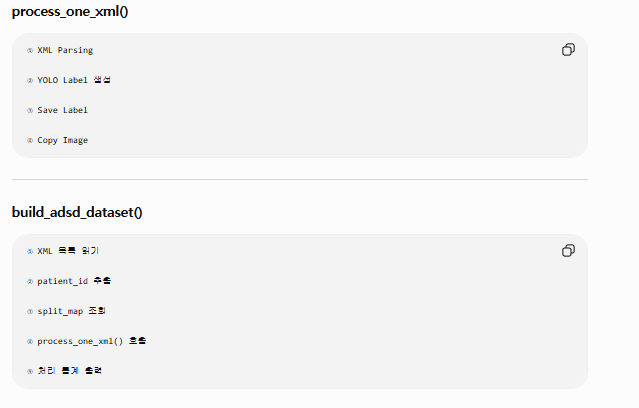

In [ ]:
# 이전 테스트 파일 삭제
# =====================================================
# Step 05-4-1. Clean Output Folder
# =====================================================

import shutil

for split in ["train", "val", "test"]:

    img_dir = OUTPUT_DIR / "images" / split
    lbl_dir = OUTPUT_DIR / "labels" / split

    shutil.rmtree(img_dir)
    shutil.rmtree(lbl_dir)

    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

print("Output folder cleaned.")

Output folder cleaned.


In [ ]:
# =====================================================
# Step 05-4. Build ADSD Dataset
# =====================================================

from collections import defaultdict
from tqdm import tqdm

def build_adsd_dataset():

    dataset_dir = ADSD_DIR / "dataset"
    xml_files = sorted(dataset_dir.glob("*.xml"))

    stats = defaultdict(int)
    skipped = 0

    print("=" * 60)
    print(f"Processing {len(xml_files)} XML files")
    print("=" * 60)

    for xml_path in tqdm(xml_files):

        # -------------------------------------------------
        # 1. Patient Split 확인
        # -------------------------------------------------
        patient_id = "_".join(xml_path.stem.split("_")[:2])

        if patient_id not in split_map:
            skipped += 1
            continue

        split = split_map[patient_id]

        # -------------------------------------------------
        # 2. XML 하나 처리
        # -------------------------------------------------
        success = process_one_xml(
            xml_path,
            split
        )

        if success:
            stats[split] += 1
        else:
            skipped += 1

    print("\n" + "=" * 60)
    print("Dataset Summary")
    print("=" * 60)

    for split in ["train", "val", "test"]:
        print(f"{split:<6}: {stats[split]}")

    print(f"Skipped : {skipped}")

    print("\n✅ Step 05-4 Complete")

In [ ]:
build_adsd_dataset()

Processing 8325 XML files


100%|██████████| 8325/8325 [07:44<00:00, 17.91it/s]


Dataset Summary
train : 5829
val   : 1261
test  : 1235
Skipped : 0

✅ Step 05-4 Complete


In [ ]:
# =====================================================
# Step 05-5. Verify Dataset
# =====================================================

def verify_dataset():

    print("=" * 60)

    total_images = 0
    total_labels = 0

    for split in ["train", "val", "test"]:

        n_images = len(list((OUTPUT_DIR / "images" / split).glob("*.bmp")))
        n_labels = len(list((OUTPUT_DIR / "labels" / split).glob("*.txt")))

        total_images += n_images
        total_labels += n_labels

        print(f"[{split.upper()}]")
        print(f"Images : {n_images}")
        print(f"Labels : {n_labels}")

        if n_images == n_labels:
            print("Status : OK")
        else:
            print("Status : Mismatch")

        print("-" * 40)

    print(f"Total Images : {total_images}")
    print(f"Total Labels : {total_labels}")

In [ ]:
verify_dataset()

[TRAIN]
Images : 5829
Labels : 5829
Status : OK
----------------------------------------
[VAL]
Images : 1261
Labels : 1261
Status : OK
----------------------------------------
[TEST]
Images : 1235
Labels : 1235
Status : OK
----------------------------------------
Total Images : 8325
Total Labels : 8325


# Step 6. Create dataset.yaml

In [ ]:
# =====================================================
# Step 06. Create dataset.yaml
# =====================================================

import yaml

dataset_yaml = {
    "path": str(OUTPUT_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "stenosis"
    }
}

yaml_path = OUTPUT_DIR / "dataset.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(
        dataset_yaml,
        f,
        sort_keys=False
    )

print("=" * 60)
print("dataset.yaml 생성 완료")
print(yaml_path)
print("=" * 60)

dataset.yaml 생성 완료
/content/drive/MyDrive/DL_project/YOLO11_ADSD/dataset.yaml


In [ ]:
print(yaml_path.read_text())

path: /content/drive/MyDrive/DL_project/YOLO11_ADSD
train: images/train
val: images/val
test: images/test
names:
  0: stenosis



# Step 7. YOLOv11 ADSD Pretraining

In [ ]:
# =====================================================
# Step 07-1. Install Ultralytics
# =====================================================

!pip install -q ultralytics

from ultralytics import YOLO
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA L4


In [ ]:
# =====================================================
# Step 07-2. Load YOLO11
# =====================================================

model = YOLO("yolo11s.pt")

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [ ]:
# =====================================================
# Step 07-3. Training Configuration
# =====================================================

MODEL = "yolo11s.pt"

EPOCHS = 50
IMGSZ = 640
BATCH = 16

PROJECT = str(PROJECT_DIR / "runs")
NAME = "YOLO11_ADSD_pretrain"

DEVICE = 0
WORKERS = 4
PATIENCE = 20

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Model    : {MODEL}")
print(f"Epochs   : {EPOCHS}")
print(f"ImageSize: {IMGSZ}")
print(f"Batch    : {BATCH}")
print(f"Device   : GPU {DEVICE}")

Training Configuration
Model    : yolo11s.pt
Epochs   : 50
ImageSize: 640
Batch    : 16
Device   : GPU 0


In [ ]:
# =====================================================
# Step 07-4. YOLO11 ADSD Pretraining
# =====================================================

model = YOLO(MODEL)

results = model.train(

    data = str(OUTPUT_DIR / "dataset.yaml"),

    epochs = EPOCHS,
    imgsz = IMGSZ,
    batch = BATCH,

    device = DEVICE,
    workers = WORKERS,

    project = PROJECT,
    name = NAME,

    patience = PATIENCE,

    pretrained = True,
    verbose = True
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/YOLO11_ADSD/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11_ADSD_pretrain, nbs=64, nms=False, opset=None, o

In [ ]:
# bounding box analysis

In [ ]:
## =====================================================
# Step 07-5. ADSD Bounding Box Analysis
# =====================================================

from tqdm import tqdm

box_widths = []
box_heights = []
box_areas = []

xml_files = sorted((ADSD_DIR / "dataset").glob("*.xml"))

for xml_path in tqdm(xml_files):

    width, height, objects = parse_xml(xml_path)

    for obj in objects:

        x, y, w, h = convert_bbox_to_yolo(
            obj["bbox"],
            width,
            height
        )

        box_widths.append(w)
        box_heights.append(h)
        box_areas.append(w * h)

100%|██████████| 8325/8325 [03:46<00:00, 36.71it/s] 


In [ ]:
import numpy as np

print("=" * 60)
print("ADSD Bounding Box Statistics")
print("=" * 60)

print(f"Number of Boxes : {len(box_areas)}")
print()

print(f"Width")
print(f"Mean : {np.mean(box_widths):.5f}")
print(f"Min  : {np.min(box_widths):.5f}")
print(f"Max  : {np.max(box_widths):.5f}")
print()

print(f"Height")
print(f"Mean : {np.mean(box_heights):.5f}")
print(f"Min  : {np.min(box_heights):.5f}")
print(f"Max  : {np.max(box_heights):.5f}")
print()

print(f"Area")
print(f"Mean : {np.mean(box_areas):.6f}")
print(f"Min  : {np.min(box_areas):.6f}")
print(f"Max  : {np.max(box_areas):.6f}")

ADSD Bounding Box Statistics
Number of Boxes : 8326

Width
Mean : 0.06129
Min  : 0.00977
Max  : 0.19000

Height
Mean : 0.05250
Min  : 0.01100
Max  : 0.26953

Area
Mean : 0.003359
Min  : 0.000156
Max  : 0.030183


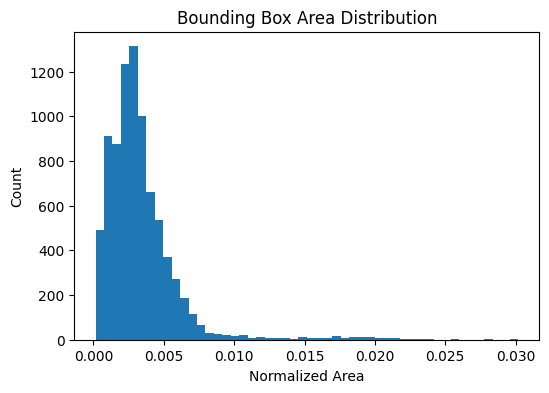

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(box_areas, bins=50)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Area")
plt.ylabel("Count")
plt.show()

# Step 8. Fine-tuning

In [ ]:
# Step 08-1. 기존 CADICA YOLO 데이터셋 확인
from pathlib import Path

CADICA_YOLO_DIR = PROJECT_DIR / "09_detection_dataset"

print("="*60)

for p in sorted(CADICA_YOLO_DIR.iterdir()):
    print(p.name)

dataset.yaml
images
labels


In [ ]:
# Step 08-2.이미지/라벨 개수 확인
for split in ["train", "val", "test"]:

    n_images = len(list((CADICA_YOLO_DIR / "images" / split).glob("*")))
    n_labels = len(list((CADICA_YOLO_DIR / "labels" / split).glob("*.txt")))

    print("="*40)
    print(split.upper())
    print("Images :", n_images)
    print("Labels :", n_labels)

TRAIN
Images : 13316
Labels : 13316
VAL
Images : 1396
Labels : 1396
TEST
Images : 1087
Labels : 1087


In [ ]:
# Step 08-3. 비병변 이미지 확인
import pandas as pd

split_df = pd.read_csv(PROJECT_DIR /"common_split.csv")

non_lesion = split_df[split_df["label"] == "non-lesion"]

print(non_lesion.head())

  patient_id video_id       label view  n_frames  has_groundtruth  split
4         p1       v1  non-lesion  LCA        55            False  train
5         p1       v5  non-lesion  RCA        25            False  train
6         p1       v6  non-lesion  RCA        27            False  train
7         p1       v9  non-lesion  LCA        55            False  train
8         p1      v13  non-lesion  RCA        25            False  train


In [ ]:
# Step 08-4. 실제 이미지와 라벨 확인
from pathlib import Path

train_imgs = list((CADICA_YOLO_DIR / "images" / "train").glob("*"))

print(train_imgs[:20])

[PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00009.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00010.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00011.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00012.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00013.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00014.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00015.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00016.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00017.png'), PosixPath('/content/drive/MyDrive/DL_project/09_detection_dataset/images/train/p41_v20_00018.png'),

In [ ]:
# Step 08-5. TXT 내용 확인
import glob
from pathlib import Path

for txt in sorted((CADICA_YOLO_DIR / "labels/train").glob("p1_v1*.txt"))[:5]:
    print(txt.name)
    print(repr(txt.read_text()))
    print("-"*30)

p1_v10_00001.txt
''
------------------------------
p1_v10_00002.txt
''
------------------------------
p1_v10_00003.txt
''
------------------------------
p1_v10_00004.txt
''
------------------------------
p1_v10_00005.txt
''
------------------------------


In [ ]:
# Step 09-1. CADICA dataset.yaml 확인
# =====================================================
# Step 09-1. Check CADICA dataset.yaml
# =====================================================

from pathlib import Path

CADICA_DIR = PROJECT_DIR / "09_detection_dataset"

yaml_path = CADICA_DIR / "dataset.yaml"

print(yaml_path.read_text())


path: /content/drive/MyDrive/DL_project/09_detection_dataset

train: images/train
val: images/val
test: images/test

names:
  0: lesion



In [ ]:
# 0: lesion을 stenosis로 수정

# =====================================================
# Step 09-1. Update CADICA dataset.yaml
# =====================================================

import yaml

yaml_path = CADICA_DIR / "dataset.yaml"

dataset_yaml = {
    "path": str(CADICA_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "stenosis"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(
        dataset_yaml,
        f,
        sort_keys=False
    )

print("dataset.yaml 수정 완료")
print()

print(yaml_path.read_text())

dataset.yaml 수정 완료

path: /content/drive/MyDrive/DL_project/09_detection_dataset
train: images/train
val: images/val
test: images/test
names:
  0: stenosis



In [ ]:
# ADSD best.pt 경로 확인
from pathlib import Path

BEST_WEIGHT = (
    PROJECT_DIR /
    "runs" /
    "YOLO11_ADSD_pretrain" /
    "weights" /
    "best.pt"
)

print(BEST_WEIGHT)
print(BEST_WEIGHT.exists())

/content/drive/MyDrive/DL_project/runs/YOLO11_ADSD_pretrain/weights/best.pt
True


In [ ]:
# Step 09-2. Backup ADSD Best Weight
# weights 폴더 생성
# =====================================================
# Step 09-2. Backup ADSD Best Weight
# =====================================================

from pathlib import Path
import shutil

WEIGHT_DIR = PROJECT_DIR / "weights"
WEIGHT_DIR.mkdir(exist_ok=True)

BEST_WEIGHT = (
    PROJECT_DIR /
    "runs" /
    "YOLO11_ADSD_pretrain" /
    "weights" /
    "best.pt"
)

BACKUP_WEIGHT = WEIGHT_DIR / "ADSD640_best.pt"

shutil.copy2(
    BEST_WEIGHT,
    BACKUP_WEIGHT
)

print("Backup Complete!")
print(BACKUP_WEIGHT)

Backup Complete!
/content/drive/MyDrive/DL_project/weights/ADSD640_best.pt


In [ ]:
# Step 09-3. CADICA640 Fine-tuning
# =====================================================
# Step 09-3. CADICA640 Fine-tuning Configuration
# =====================================================

from ultralytics import YOLO

BEST_WEIGHT = PROJECT_DIR / "weights" / "ADSD640_best.pt"

model = YOLO(str(BEST_WEIGHT))

EPOCHS = 50
IMGSZ = 640
BATCH = 16

DEVICE = 0
WORKERS = 4
PATIENCE = 10

PROJECT = str(PROJECT_DIR / "runs")
NAME = "YOLO11_CADICA640"

print("="*60)
print("CADICA Fine-tuning Configuration")
print("="*60)
print(f"Weight   : {BEST_WEIGHT}")
print(f"Epochs   : {EPOCHS}")
print(f"Image    : {IMGSZ}")
print(f"Batch    : {BATCH}")
print(f"Patience : {PATIENCE}")

CADICA Fine-tuning Configuration
Weight   : /content/drive/MyDrive/DL_project/weights/ADSD640_best.pt
Epochs   : 50
Image    : 640
Batch    : 16
Patience : 10


In [ ]:
# =====================================================
# Step 09-4. Fine-tuning on CADICA
# =====================================================

results = model.train(

    data=str(CADICA_DIR / "dataset.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    patience=PATIENCE,

    project=PROJECT,
    name=NAME,

    verbose=True
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/09_detection_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DL_project/weights/ADSD640_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

# Step 10. Result

In [ ]:
# 백업
import shutil
shutil.copy2(PROJECT_DIR/"runs"/"YOLO11_CADICA640"/"weights"/"best.pt",
             PROJECT_DIR/"weights"/"CADICA640_best.pt")

PosixPath('/content/drive/MyDrive/DL_project/weights/CADICA640_best.pt')

# Step 11. Threshold 최적화

In [ ]:
# =====================================================
# Step 11-1. Confidence Threshold Optimization
# =====================================================

from ultralytics import YOLO
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

MODEL_PATH = PROJECT_DIR / "runs" / "YOLO11_CADICA640" / "weights" / "best.pt"

model = YOLO(str(MODEL_PATH))

print("Model Loaded!")
print(MODEL_PATH)

Model Loaded!
/content/drive/MyDrive/DL_project/runs/YOLO11_CADICA640/weights/best.pt


In [ ]:
# =====================================================
# Step 11-2. Threshold Sweep
# =====================================================

import pandas as pd
from pathlib import Path

DATA_YAML = PROJECT_DIR / "09_detection_dataset" / "dataset.yaml"

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []

for conf in thresholds:
    print("=" * 60)
    print(f"Confidence Threshold : {conf:.2f}")

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        conf=conf,
        verbose=False
    )

    precision = metrics.box.mp
    recall = metrics.box.mr
    map50 = metrics.box.map50

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    results.append({
        "Threshold": conf,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "F1": f1
    })

df = pd.DataFrame(results)

display(df)

save_path = PROJECT_DIR / "threshold_results.csv"
df.to_csv(save_path, index=False)

print(f"\nSaved to: {save_path}")

Confidence Threshold : 0.05
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 0.1±0.0 MB/s, size: 96.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset/labels/val.cache... 1396 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 244.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 1.3it/s 1:08
                   all       1396        506       0.11      0.239     0.0581     0.0177
Speed: 0.7ms preprocess, 4.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
Confidence Threshold : 0.10
Ultralytics 8.4.98 🚀 Pytho

,Threshold,Precision,Recall,mAP50,F1
0,0.05,0.110000,0.239130,0.058080,0.150685
1,0.10,0.141473,0.144269,0.046771,0.142857
2,0.15,0.151007,0.088933,0.037913,0.111940
3,0.20,0.205882,0.069170,0.034365,0.103550
4,0.25,0.243243,0.053360,0.032058,0.087520
5,0.30,0.385965,0.043478,0.029262,0.078153
6,0.40,0.611111,0.021739,0.021083,0.041985
7,0.50,1.000000,0.001976,0.005000,0.003945



Saved to: /content/drive/MyDrive/DL_project/threshold_results.csv


In [ ]:
# 세밀 탐색
# =====================================================
# Step 11-3. Fine Threshold Sweep (0.01 ~ 0.05)
# =====================================================

import pandas as pd

DATA_YAML = PROJECT_DIR / "09_detection_dataset" / "dataset.yaml"

thresholds = [0.01, 0.02, 0.03, 0.04, 0.05]

results = []

for conf in thresholds:
    print("=" * 60)
    print(f"Confidence Threshold : {conf:.2f}")

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        conf=conf,
        verbose=False
    )

    precision = metrics.box.mp
    recall = metrics.box.mr
    map50 = metrics.box.map50

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    results.append({
        "Threshold": conf,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "F1": f1
    })

df_fine = pd.DataFrame(results)

display(df_fine)

save_path = PROJECT_DIR / "threshold_results_fine.csv"
df_fine.to_csv(save_path, index=False)

print(f"\nSaved to : {save_path}")

Confidence Threshold : 0.01
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 51.0±17.7 MB/s, size: 91.5 KB)
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset/labels/val.cache... 1396 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 450.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 5.4it/s 16.2s
                   all       1396        506      0.122      0.191     0.0737     0.0232
Speed: 0.9ms preprocess, 4.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-9
Confidence Threshold : 0.02
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.1 ms, read: 35.5±20.4 MB/s, size: 98.6 KB). Use local storage instead of remote/mounted storage for better performance. S

,Threshold,Precision,Recall,mAP50,F1
0,0.01,0.122057,0.190955,0.073742,0.148923
1,0.02,0.122816,0.197628,0.068601,0.151489
2,0.03,0.114195,0.231225,0.065227,0.152885
3,0.04,0.102526,0.272727,0.062324,0.149028
4,0.05,0.110000,0.239130,0.058080,0.150685



Saved to : /content/drive/MyDrive/DL_project/threshold_results_fine.csv


In [ ]:
# =====================================================
# Step 11-2. Threshold Sweep
# =====================================================

import pandas as pd
from pathlib import Path

DATA_YAML = PROJECT_DIR / "09_detection_dataset" / "dataset.yaml"

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []

for conf in thresholds:
    print("=" * 60)
    print(f"Confidence Threshold : {conf:.2f}")

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        conf=conf,
        verbose=False
    )

    precision = metrics.box.mp
    recall = metrics.box.mr
    map50 = metrics.box.map50
    map5095 = metrics.box.map

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    results.append({
        "Threshold": conf,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "mAP50-95": map5095,
        "F1": f1
    })

df = pd.DataFrame(results)

display(df)

save_path = PROJECT_DIR / "threshold_results.csv"
df.to_csv(save_path, index=False)

print(f"\nSaved to: {save_path}")

Confidence Threshold : 0.05
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 51.3±15.5 MB/s, size: 94.8 KB)
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset/labels/val.cache... 1396 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 292.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 5.4it/s 16.4s
                   all       1396        506       0.11      0.239     0.0581     0.0177
Speed: 0.9ms preprocess, 4.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val-14
Confidence Threshold : 0.10
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.1 ms, read: 44.0±12.1 MB/s, size: 101.1 KB). Use local storage instead of remote/mounted storage for better performance.

,Threshold,Precision,Recall,mAP50,mAP50-95,F1
0,0.05,0.110000,0.239130,0.058080,0.017671,0.150685
1,0.10,0.141473,0.144269,0.046771,0.013858,0.142857
2,0.15,0.151007,0.088933,0.037913,0.011556,0.111940
3,0.20,0.205882,0.069170,0.034365,0.010720,0.103550
4,0.25,0.243243,0.053360,0.032058,0.009857,0.087520
5,0.30,0.385965,0.043478,0.029262,0.009222,0.078153
6,0.40,0.611111,0.021739,0.021083,0.006599,0.041985
7,0.50,1.000000,0.001976,0.005000,0.001000,0.003945



Saved to: /content/drive/MyDrive/DL_project/threshold_results.csv


In [ ]:
# 세밀 탐색
# =====================================================
# Step 11-2. Threshold Sweep
# =====================================================

import pandas as pd
from pathlib import Path

DATA_YAML = PROJECT_DIR / "09_detection_dataset" / "dataset.yaml"

thresholds = [0.01, 0.02, 0.03, 0.04, 0.05]

results = []

for conf in thresholds:
    print("=" * 60)
    print(f"Confidence Threshold : {conf:.2f}")

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        conf=conf,
        verbose=False
    )

    precision = metrics.box.mp
    recall = metrics.box.mr
    map50 = metrics.box.map50
    map5095 = metrics.box.map

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    results.append({
        "Threshold": conf,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "mAP50-95": map5095,
        "F1": f1
    })

df = pd.DataFrame(results)

display(df)

save_path = PROJECT_DIR / "threshold_results.csv"
df.to_csv(save_path, index=False)

print(f"\nSaved to: {save_path}")

Confidence Threshold : 0.01
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 30.2±18.5 MB/s, size: 95.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset/labels/val.cache... 1396 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 366.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 5.4it/s 16.3s
                   all       1396        506      0.122      0.191     0.0737     0.0232
Speed: 0.9ms preprocess, 4.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val-22
Confidence Threshold : 0.02
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image acce

,Threshold,Precision,Recall,mAP50,mAP50-95,F1
0,0.01,0.122057,0.190955,0.073742,0.023169,0.148923
1,0.02,0.122816,0.197628,0.068601,0.021444,0.151489
2,0.03,0.114195,0.231225,0.065227,0.020466,0.152885
3,0.04,0.102526,0.272727,0.062324,0.019168,0.149028
4,0.05,0.110000,0.239130,0.058080,0.017671,0.150685



Saved to: /content/drive/MyDrive/DL_project/threshold_results.csv


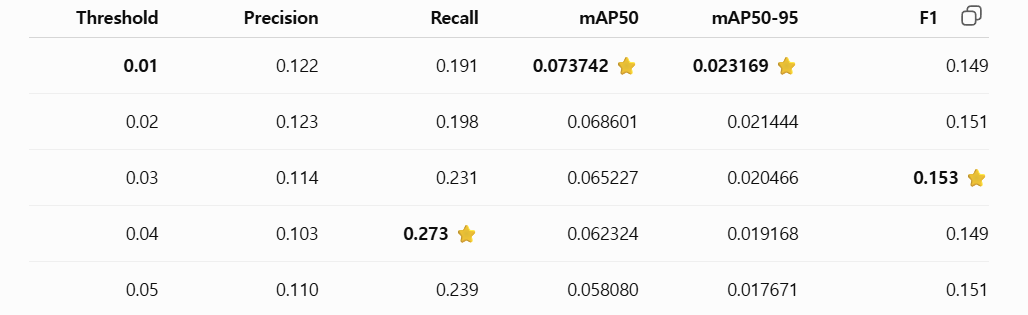

# Step 12. TTA

In [ ]:
# =====================================================
# Step 12-1. Test-Time Augmentation (TTA)
# =====================================================

DATA_YAML = PROJECT_DIR / "09_detection_dataset" / "dataset.yaml"

metrics_tta = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    conf=0.01,
    augment=True,
    verbose=False
)

precision = metrics_tta.box.mp
recall = metrics_tta.box.mr
map50 = metrics_tta.box.map50
map5095 = metrics_tta.box.map

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

print("=" * 60)
print("TTA Result")
print("=" * 60)

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"mAP50     : {map50:.6f}")
print(f"mAP50-95  : {map5095:.6f}")
print(f"F1 Score  : {f1:.6f}")

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 39.4±11.8 MB/s, size: 95.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset/labels/val.cache... 1396 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1396/1396 450.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.9it/s 22.8s
                   all       1396        506      0.112      0.237     0.0733     0.0225
Speed: 0.8ms preprocess, 10.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-27
TTA Result
Precision : 0.112071
Recall    : 0.237465
mAP50     : 0.073309
mAP50-95  : 0.022544
F1 Score  : 0.152275


In [ ]:
# =====================================================
# Step 12-2. Compare Baseline vs TTA
# =====================================================

comparison = pd.DataFrame([
    {
        "Experiment": "Threshold Optimization",
        "Conf": 0.01,
        "TTA": False,
        "Precision": 0.122057,
        "Recall": 0.190955,
        "mAP50": 0.073742,
        "mAP50-95": 0.023169,
        "F1": 0.148923
    },
    {
        "Experiment": "TTA",
        "Conf": 0.01,
        "TTA": True,
        "Precision": precision,
        "Recall": recall,
        "mAP50": map50,
        "mAP50-95": map5095,
        "F1": f1
    }
])

display(comparison)

comparison.to_csv(
    PROJECT_DIR / "tta_comparison.csv",
    index=False
)

print("Saved!")

,Experiment,Conf,TTA,Precision,Recall,mAP50,mAP50-95,F1
0,Threshold Optimization,0.01,False,0.122057,0.190955,0.073742,0.023169,0.148923
1,TTA,0.01,True,0.112071,0.237465,0.073309,0.022544,0.152275


Saved!


# Step 13. Data Optimization

In [ ]:
# 현재 train 데이터 다시 확인

# =====================================================
# Step 13-1. Analyze Train Dataset
# =====================================================

from pathlib import Path

DATASET_DIR = PROJECT_DIR / "09_detection_dataset"

train_image_dir = DATASET_DIR / "images" / "train"
train_label_dir = DATASET_DIR / "labels" / "train"

lesion = 0
background = 0

for txt in train_label_dir.glob("*.txt"):
    if txt.stat().st_size == 0:
        background += 1
    else:
        lesion += 1

print("="*60)
print("Train Dataset")
print("="*60)

print(f"Lesion Images     : {lesion}")
print(f"Background Images : {background}")

ratio = background / lesion

print(f"\nBackground / Lesion Ratio : {ratio:.2f}")

Train Dataset
Lesion Images     : 3077
Background Images : 10239

Background / Lesion Ratio : 3.33


In [ ]:
# 1:2 dataset  생성
# =====================================================
# Step 13-2. Create Balanced Dataset (Ratio 1:2)
# =====================================================

import shutil
import random
import pandas as pd
from pathlib import Path

random.seed(42)

In [ ]:
# =====================================================
# Paths
# =====================================================

SRC_DIR = PROJECT_DIR / "09_detection_dataset"
DST_DIR = PROJECT_DIR / "10_detection_dataset_ratio2"

train_img_src = SRC_DIR / "images" / "train"
train_lbl_src = SRC_DIR / "labels" / "train"

val_img_src = SRC_DIR / "images" / "val"
val_lbl_src = SRC_DIR / "labels" / "val"

test_img_src = SRC_DIR / "images" / "test"
test_lbl_src = SRC_DIR / "labels" / "test"

In [ ]:
# 새 폴더 생성
# =====================================================
# Create Folder Structure
# =====================================================

if DST_DIR.exists():
    shutil.rmtree(DST_DIR)

for split in ["train", "val", "test"]:
    (DST_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DST_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

In [ ]:
# 병변/배경 분리
# =====================================================
# Split Lesion / Background
# =====================================================

lesion_files = []
background_files = []

for txt in train_lbl_src.glob("*.txt"):

    if txt.stat().st_size == 0:
        background_files.append(txt.stem)

    else:
        lesion_files.append(txt.stem)

print("Lesion :", len(lesion_files))
print("Background :", len(background_files))

Lesion : 3077
Background : 10239


In [ ]:
# 병변 그대로 유지, 배경은 병변의 2배만 선택
# =====================================================
# Select Background (Ratio 1:2)
# =====================================================

target_background = len(lesion_files) * 2

selected_background = random.sample(
    background_files,
    target_background
)

print("Selected Background :", len(selected_background))

Selected Background : 6154


In [ ]:
# =====================================================
# Copy Train Dataset
# =====================================================

sampling_log = []

selected_background = set(selected_background)

for stem in lesion_files:

    shutil.copy(
        train_img_src / f"{stem}.png",
        DST_DIR / "images" / "train" / f"{stem}.png"
    )

    shutil.copy(
        train_lbl_src / f"{stem}.txt",
        DST_DIR / "labels" / "train" / f"{stem}.txt"
    )

    sampling_log.append([stem, "lesion", True])

for stem in background_files:

    if stem in selected_background:

        shutil.copy(
            train_img_src / f"{stem}.png",
            DST_DIR / "images" / "train" / f"{stem}.png"
        )

        shutil.copy(
            train_lbl_src / f"{stem}.txt",
            DST_DIR / "labels" / "train" / f"{stem}.txt"
        )

        sampling_log.append([stem, "background", True])

    else:

        sampling_log.append([stem, "background", False])

In [ ]:
# train 생성확인
# =====================================================
# Verify Train Dataset
# =====================================================

train_images = len(list((DST_DIR / "images" / "train").glob("*.png")))
train_labels = len(list((DST_DIR / "labels" / "train").glob("*.txt")))

print("=" * 60)
print("Balanced Train Dataset")
print("=" * 60)

print(f"Train Images : {train_images}")
print(f"Train Labels : {train_labels}")
print(f"Expected     : {len(lesion_files) + len(selected_background)}")

Balanced Train Dataset
Train Images : 9231
Train Labels : 9231
Expected     : 9231


In [ ]:
# =====================================================
# Save Sampling Log
# =====================================================

import pandas as pd

log_df = pd.DataFrame(
    sampling_log,
    columns=["image", "type", "selected"]
)

log_path = DST_DIR / "sampling_log.csv"
log_df.to_csv(log_path, index=False)

print(f"Saved: {log_path}")
print(f"Total records: {len(log_df)}")

Saved: /content/drive/MyDrive/DL_project/10_detection_dataset_ratio2/sampling_log.csv
Total records: 13316


In [ ]:
# dataset.yaml 생성
# =====================================================
# Create dataset.yaml
# =====================================================

yaml_text = f"""
train: {str((DST_DIR / "images" / "train").resolve())}
val: {str((SRC_DIR / "images" / "val").resolve())}
test: {str((SRC_DIR / "images" / "test").resolve())}

names:
  0: stenosis
"""

yaml_path = DST_DIR / "dataset.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text.strip())

print("dataset.yaml created")
print("="*50)
print(yaml_text)

dataset.yaml created

train: /content/drive/MyDrive/DL_project/10_detection_dataset_ratio2/images/train
val: /content/drive/MyDrive/DL_project/09_detection_dataset/images/val
test: /content/drive/MyDrive/DL_project/09_detection_dataset/images/test

names:
  0: stenosis



In [ ]:
# 확인
# =====================================================
# Check dataset.yaml
# =====================================================

with open(yaml_path, "r") as f:
    print(f.read())

train: /content/drive/MyDrive/DL_project/10_detection_dataset_ratio2/images/train
val: /content/drive/MyDrive/DL_project/09_detection_dataset/images/val
test: /content/drive/MyDrive/DL_project/09_detection_dataset/images/test

names:
  0: stenosis


In [ ]:
# 경로 검증 - 학습 전 데이터 확인
# =====================================================
# Check Dataset Paths
# =====================================================

from pathlib import Path

train_dir = DST_DIR / "images" / "train"
val_dir = SRC_DIR / "images" / "val"
test_dir = SRC_DIR / "images" / "test"

print(f"Train : {len(list(train_dir.glob('*.png')))}")
print(f"Val   : {len(list(val_dir.glob('*.png')))}")
print(f"Test  : {len(list(test_dir.glob('*.png')))}")

Train : 9231
Val   : 1396
Test  : 1087


# Step 14. Ratio2 Fine-tuning
14-1 Dataset 확인
14-2 Configuration
14-3 Fine-tuning


In [ ]:
# ============================================================
# Step 14-1. Ratio2 Fine-tuning Configuration
# ============================================================

from ultralytics import YOLO

# ADSD Pretrained Weight
BEST_WEIGHT = PROJECT_DIR / "weights" / "ADSD640_best.pt"

# Ratio2 Dataset
RATIO2_DIR = PROJECT_DIR / "10_detection_dataset_ratio2"

# Load model
model = YOLO(str(BEST_WEIGHT))

# Training Configuration
EPOCHS = 50
IMGSZ = 640
BATCH = 16

DEVICE = 0
WORKERS = 4
PATIENCE = 20

PROJECT = str(PROJECT_DIR / "runs")
NAME = "YOLO11_CADICA_ratio2"

print("=" * 60)
print("Step 14. Ratio2 Fine-tuning")
print("=" * 60)
print(f"Pretrained Weight : {BEST_WEIGHT}")
print(f"Dataset           : {RATIO2_DIR}")
print(f"Epochs            : {EPOCHS}")
print(f"Image Size        : {IMGSZ}")
print(f"Batch Size        : {BATCH}")
print(f"Save Name         : {NAME}")

Step 14. Ratio2 Fine-tuning
Pretrained Weight : /content/drive/MyDrive/DL_project/weights/ADSD640_best.pt
Dataset           : /content/drive/MyDrive/DL_project/10_detection_dataset_ratio2
Epochs            : 50
Image Size        : 640
Batch Size        : 16
Save Name         : YOLO11_CADICA_ratio2


In [ ]:
# ============================================================
# Step 14-2. Ratio2 Fine-tuning
# ============================================================

results = model.train(

    data=str(RATIO2_DIR / "dataset.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    patience=PATIENCE,

    project=PROJECT,
    name=NAME,

    exist_ok=True,
    pretrained=True,
    verbose=True,
)

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/10_detection_dataset_ratio2/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DL_project/weights/ADSD640_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [ ]:
###########################여기부터 제외#################################

# Error Analysis

In [ ]:
# step 1. best.pt 불러오기
from ultralytics import YOLO

BEST_MODEL = PROJECT_DIR / "runs" / "YOLO11_CADICA_ratio2" / "weights" / "best.pt"

model = YOLO(str(BEST_MODEL))

In [ ]:
# step 2. test 데이터로 예측하기

TEST_DIR = PROJECT_DIR / "09_detection_dataset" / "images" / "test"

results = model.predict(
    source=str(TEST_DIR),

    conf=0.001,      # 모든 후보 저장 (Error Analysis용)
    iou=0.5,

    save=True,       # 예측 이미지 저장
    save_txt=True,   # 예측 bbox(txt) 저장
    save_conf=True,  # confidence 저장

    project=str(PROJECT_DIR / "runs"),
    name="error_analysis_ratio2",

    exist_ok=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1087 /content/drive/MyDrive/DL_project/09_detection_dataset/images/test/p28_v1_00001.png: 640x640 12 stenosiss, 10.0ms
image 2/1087 /content/drive/MyDrive/DL_project/09_detection_dataset/images/test/p28_v1_00002.png: 640x640 22 stenosiss, 10.7ms
image 3/1087 /content/drive/MyDrive/DL_project/09_detection_dataset/images/test/p28_v1_00003.png: 640x640 22 stenosiss, 10.9ms
image 4/1087 /content/drive/MyDrive/DL_project/09_detection_dataset/images/te

In [ ]:
from pathlib import Path

GT_LABEL_DIR = PROJECT_DIR / "09_detection_dataset" / "labels" / "test"
PRED_LABEL_DIR = PROJECT_DIR / "runs" / "error_analysis_ratio2" / "labels"

print("GT :", GT_LABEL_DIR.exists())
print("Prediction :", PRED_LABEL_DIR.exists())

print("GT labels :", len(list(GT_LABEL_DIR.glob("*.txt"))))
print("Prediction labels :", len(list(PRED_LABEL_DIR.glob("*.txt"))))

GT : True
Prediction : True
GT labels : 1087
Prediction labels : 1064


In [ ]:
from ultralytics.utils.metrics import box_iou
import torch
from pathlib import Path
import pandas as pd

IOU_THRESHOLD = 0.5

In [ ]:
def read_yolo_label(txt_path):
    boxes = []

    if not txt_path.exists():
        return boxes

    with open(txt_path) as f:
        for line in f:
            s = line.strip().split()

            if len(s) < 5:
                continue

            cls = int(float(s[0]))
            x = float(s[1])
            y = float(s[2])
            w = float(s[3])
            h = float(s[4])

            conf = float(s[5]) if len(s) == 6 else None

            x1 = x - w/2
            y1 = y - h/2
            x2 = x + w/2
            y2 = y + h/2

            boxes.append([cls, x1, y1, x2, y2, conf])

    return boxes

In [ ]:
from ultralytics.utils.metrics import box_iou
import torch
import pandas as pd

def evaluate_iou(gt_boxes, pred_boxes, iou_threshold):

    gt_tensor = torch.tensor([b[1:5] for b in gt_boxes], dtype=torch.float32) if gt_boxes else torch.empty((0,4))
    pred_tensor = torch.tensor([b[1:5] for b in pred_boxes], dtype=torch.float32) if pred_boxes else torch.empty((0,4))

    matched_gt = set()
    matched_pred = set()

    if len(gt_tensor) > 0 and len(pred_tensor) > 0:

        ious = box_iou(pred_tensor, gt_tensor)

        for p in range(len(pred_tensor)):

            best_iou, g = torch.max(ious[p], dim=0)

            if best_iou >= iou_threshold and g.item() not in matched_gt:
                matched_gt.add(g.item())
                matched_pred.add(p)

    TP = len(matched_gt)
    FP = len(pred_boxes) - len(matched_pred)
    FN = len(gt_boxes) - len(matched_gt)

    return TP, FP, FN

In [ ]:
iou_list = [0.30, 0.50, 0.75]

summary = []

gt_files = sorted(GT_LABEL_DIR.glob("*.txt"))

for iou_thr in iou_list:

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for gt_file in gt_files:

        pred_file = PRED_LABEL_DIR / gt_file.name

        gt_boxes = read_yolo_label(gt_file)
        pred_boxes = read_yolo_label(pred_file)

        tp, fp, fn = evaluate_iou(
            gt_boxes,
            pred_boxes,
            iou_thr
        )

        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)

    summary.append({
        "IoU": iou_thr,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "Precision": precision,
        "Recall": recall
    })

summary_df = pd.DataFrame(summary)

summary_df

,IoU,TP,FP,FN,Precision,Recall
0,0.30,216,14384,57,0.014795,0.791209
1,0.50,158,14442,115,0.010822,0.578755
2,0.75,45,14555,228,0.003082,0.164835


In [ ]:
###########################여기까지 제외##########################

# HE (Histogram Equalization)


HE는 관상동맥 조영영상의 혈관 대비를 높여 작은 협착을 더 잘 드러내는 효과가 있음.
특히 CADICA처럼 저대비 영상에서는 CLAHE보다 HE가 더 좋은 결과를 보고한 사례도 있었음.
구현이 간단하고, 기존 파이프라인을 거의 바꾸지 않아도 됨.
효과가 없더라도 이후 HEC와의 비교 기준이 생김.

In [ ]:
# 경로 설정
from pathlib import Path
import cv2
import shutil
from tqdm import tqdm

# ===========================
# Project Path
# ===========================
PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

# Input Dataset
RATIO2_DIR = PROJECT_DIR / "10_detection_dataset_ratio2"
ORIGINAL_DIR = PROJECT_DIR / "09_detection_dataset"

# Output Dataset
OUTPUT_DIR = PROJECT_DIR / "11_detection_dataset_ratio2_HE"

# Output Folder 생성
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Output Folder :", OUTPUT_DIR)

Output Folder : /content/drive/MyDrive/DL_project/11_detection_dataset_ratio2_HE


In [ ]:
def apply_he(img):
    """
    Histogram Equalization (HE)
    """

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    he = cv2.equalizeHist(gray)

    return cv2.cvtColor(he, cv2.COLOR_GRAY2BGR)

In [ ]:
def process_images(src_dir, dst_dir):

    images = sorted(src_dir.glob("*.png"))

    processed = 0
    skipped = 0
    errors = 0

    for img_path in tqdm(images, desc=src_dir.name):

        save_path = dst_dir / img_path.name

        if save_path.exists():
            skipped += 1
            continue

        img = cv2.imread(str(img_path))

        if img is None:
            errors += 1
            print(f"Error: {img_path}")
            continue

        he = apply_he(img)

        cv2.imwrite(str(save_path), he)

        processed += 1

    print(f"\nProcessed : {processed}")
    print(f"Skipped   : {skipped}")
    print(f"Errors    : {errors}")

In [ ]:
# ===========================
# HE Image 생성
# ===========================

print("\n========== TRAIN ==========")
process_images(
    RATIO2_DIR / "images" / "train",
    OUTPUT_DIR / "images" / "train"
)

print("\n========== VAL ==========")
process_images(
    ORIGINAL_DIR / "images" / "val",
    OUTPUT_DIR / "images" / "val"
)

print("\n========== TEST ==========")
process_images(
    ORIGINAL_DIR / "images" / "test",
    OUTPUT_DIR / "images" / "test"
)

# ===========================
# Label 복사
# ===========================

print("\n========== COPY LABELS ==========")

copy_pairs = [
    (RATIO2_DIR / "labels" / "train", OUTPUT_DIR / "labels" / "train"),
    (ORIGINAL_DIR / "labels" / "val", OUTPUT_DIR / "labels" / "val"),
    (ORIGINAL_DIR / "labels" / "test", OUTPUT_DIR / "labels" / "test"),
]

for src, dst in copy_pairs:

    dst.mkdir(parents=True, exist_ok=True)

    for label_file in tqdm(sorted(src.glob("*.txt")), desc=f"Copy {src.name}"):

        shutil.copy2(label_file, dst / label_file.name)

print("\n✅ HE Dataset 생성 완료!")


========== TRAIN ==========


train: 100%|██████████| 9231/9231 [06:07<00:00, 25.15it/s]



Processed : 9138
Skipped   : 93
Errors    : 0

========== VAL ==========


val: 100%|██████████| 1396/1396 [00:52<00:00, 26.69it/s]



Processed : 1396
Skipped   : 0
Errors    : 0

========== TEST ==========


test: 100%|██████████| 1087/1087 [00:40<00:00, 26.95it/s]



Processed : 1087
Skipped   : 0
Errors    : 0

========== COPY LABELS ==========


Copy test: 100%|██████████| 1087/1087 [00:14<00:00, 74.77it/s]


✅ HE Dataset 생성 완료!


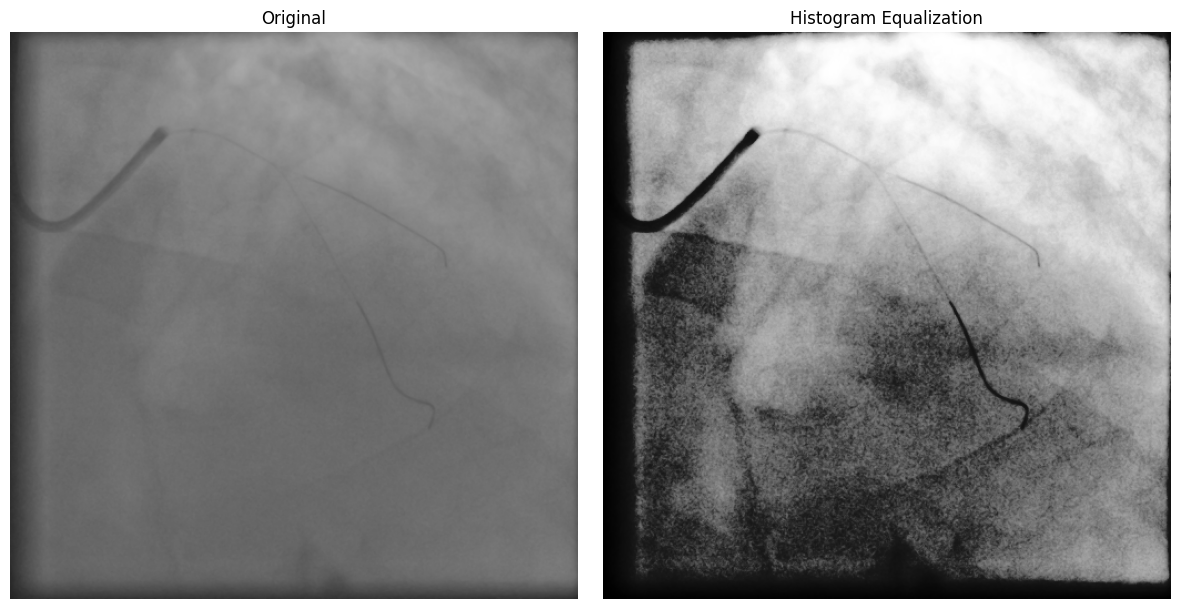

p40_v12_00003.png


In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# 원본 / HE 경로
ORIGINAL_DIR = PROJECT_DIR / "10_detection_dataset_ratio2" / "images" / "train"
HE_DIR = PROJECT_DIR / "11_detection_dataset_ratio2_HE" / "images" / "train"

# 랜덤 이미지 선택
img_name = random.choice(list(ORIGINAL_DIR.glob("*.png"))).name

orig = cv2.imread(str(ORIGINAL_DIR / img_name))
he = cv2.imread(str(HE_DIR / img_name))

# OpenCV(BGR) -> RGB
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
he = cv2.cvtColor(he, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(he)
plt.title("Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()

print(img_name)

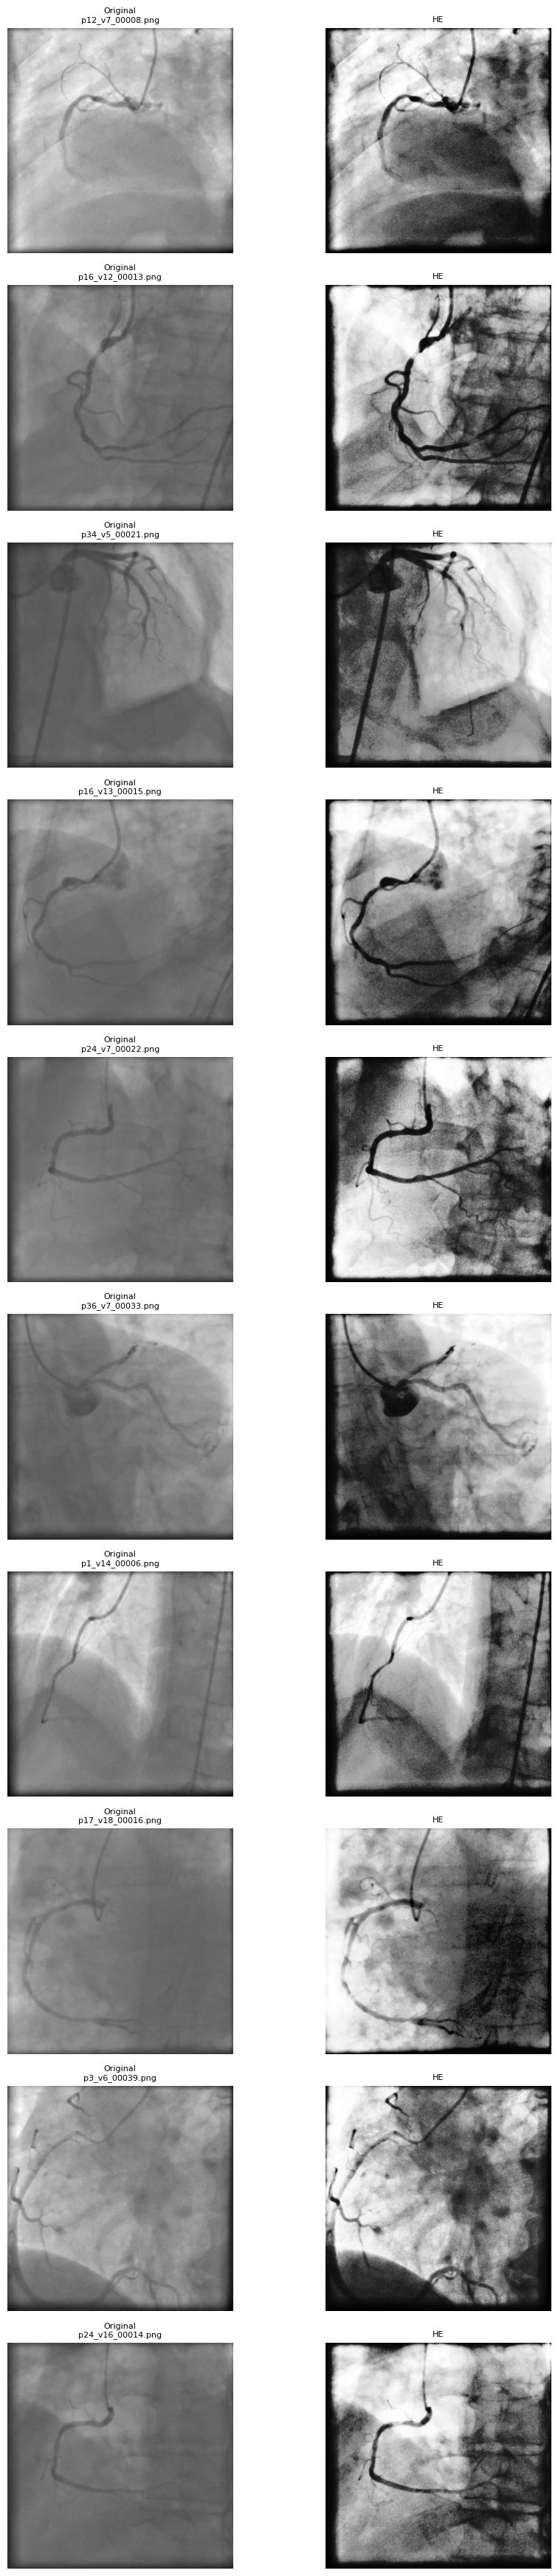

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2

ORIGINAL_DIR = PROJECT_DIR / "10_detection_dataset_ratio2" / "images" / "train"
HE_DIR = PROJECT_DIR / "11_detection_dataset_ratio2_HE" / "images" / "train"

# 랜덤으로 10장 선택
sample_files = random.sample(list(ORIGINAL_DIR.glob("*.png")), 10)

fig, axes = plt.subplots(10, 2, figsize=(10, 35))

for i, img_path in enumerate(sample_files):

    name = img_path.name

    orig = cv2.imread(str(ORIGINAL_DIR / name))
    he = cv2.imread(str(HE_DIR / name))

    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    he = cv2.cvtColor(he, cv2.COLOR_BGR2RGB)

    axes[i,0].imshow(orig)
    axes[i,0].set_title(f"Original\n{name}", fontsize=8)
    axes[i,0].axis("off")

    axes[i,1].imshow(he)
    axes[i,1].set_title("HE", fontsize=8)
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

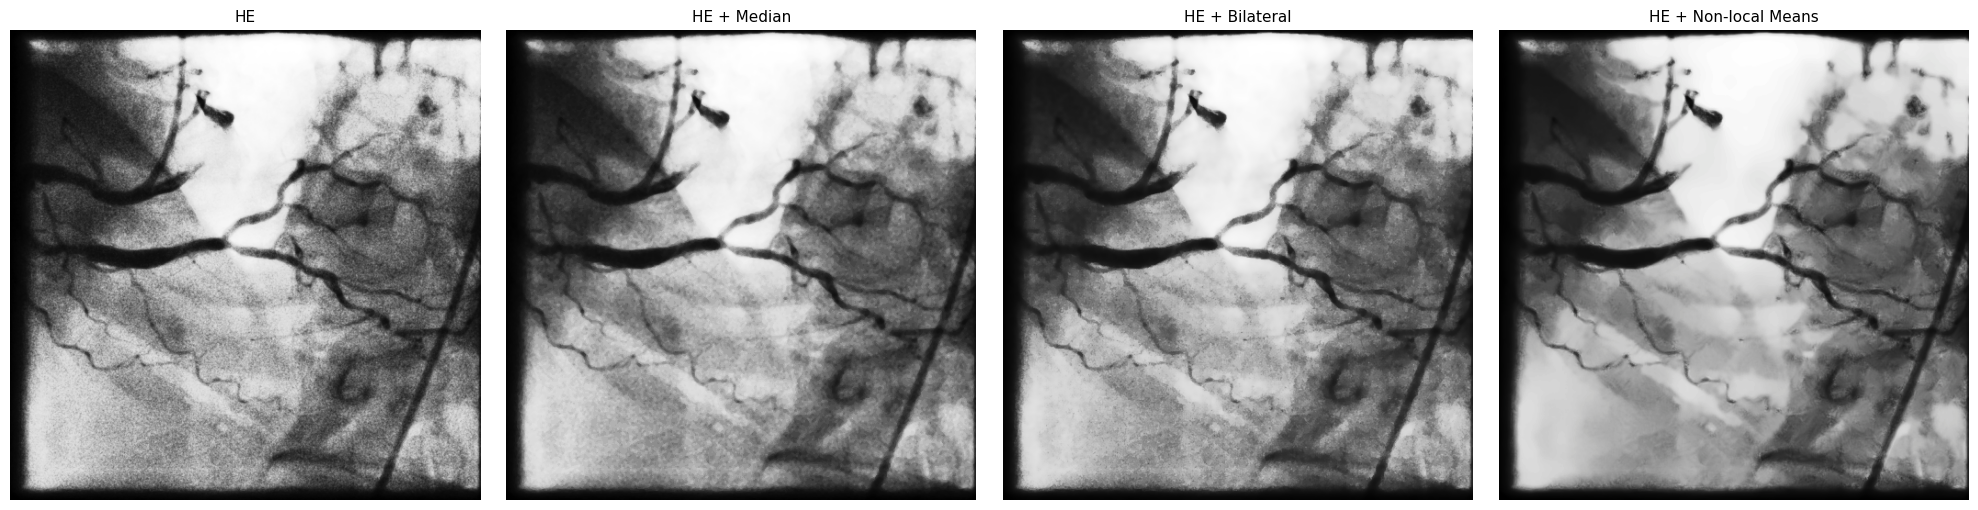

Image : p14_v2_00031.png


In [ ]:
# 배경 필터 적용
import random
import cv2
import matplotlib.pyplot as plt

HE_DIR = PROJECT_DIR / "11_detection_dataset_ratio2_HE" / "images" / "train"

# 랜덤 이미지 1장 선택
img_path = random.choice(list(HE_DIR.glob("*.png")))

# HE 이미지 읽기 (BGR)
he = cv2.imread(str(img_path))

# -----------------------------
# 필터 적용
# -----------------------------

# 1. Median
median = cv2.medianBlur(he, 3)

# 2. Bilateral
bilateral = cv2.bilateralFilter(
    he,
    d=7,
    sigmaColor=40,
    sigmaSpace=40
)

# 3. Non-local Means
nlm = cv2.fastNlMeansDenoisingColored(
    he,
    None,
    h=7,
    hColor=7,
    templateWindowSize=7,
    searchWindowSize=21
)

# RGB 변환 (출력용)
images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for img in [he, median, bilateral, nlm]
]

titles = [
    "HE",
    "HE + Median",
    "HE + Bilateral",
    "HE + Non-local Means"
]

plt.figure(figsize=(20,5))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Image : {img_path.name}")

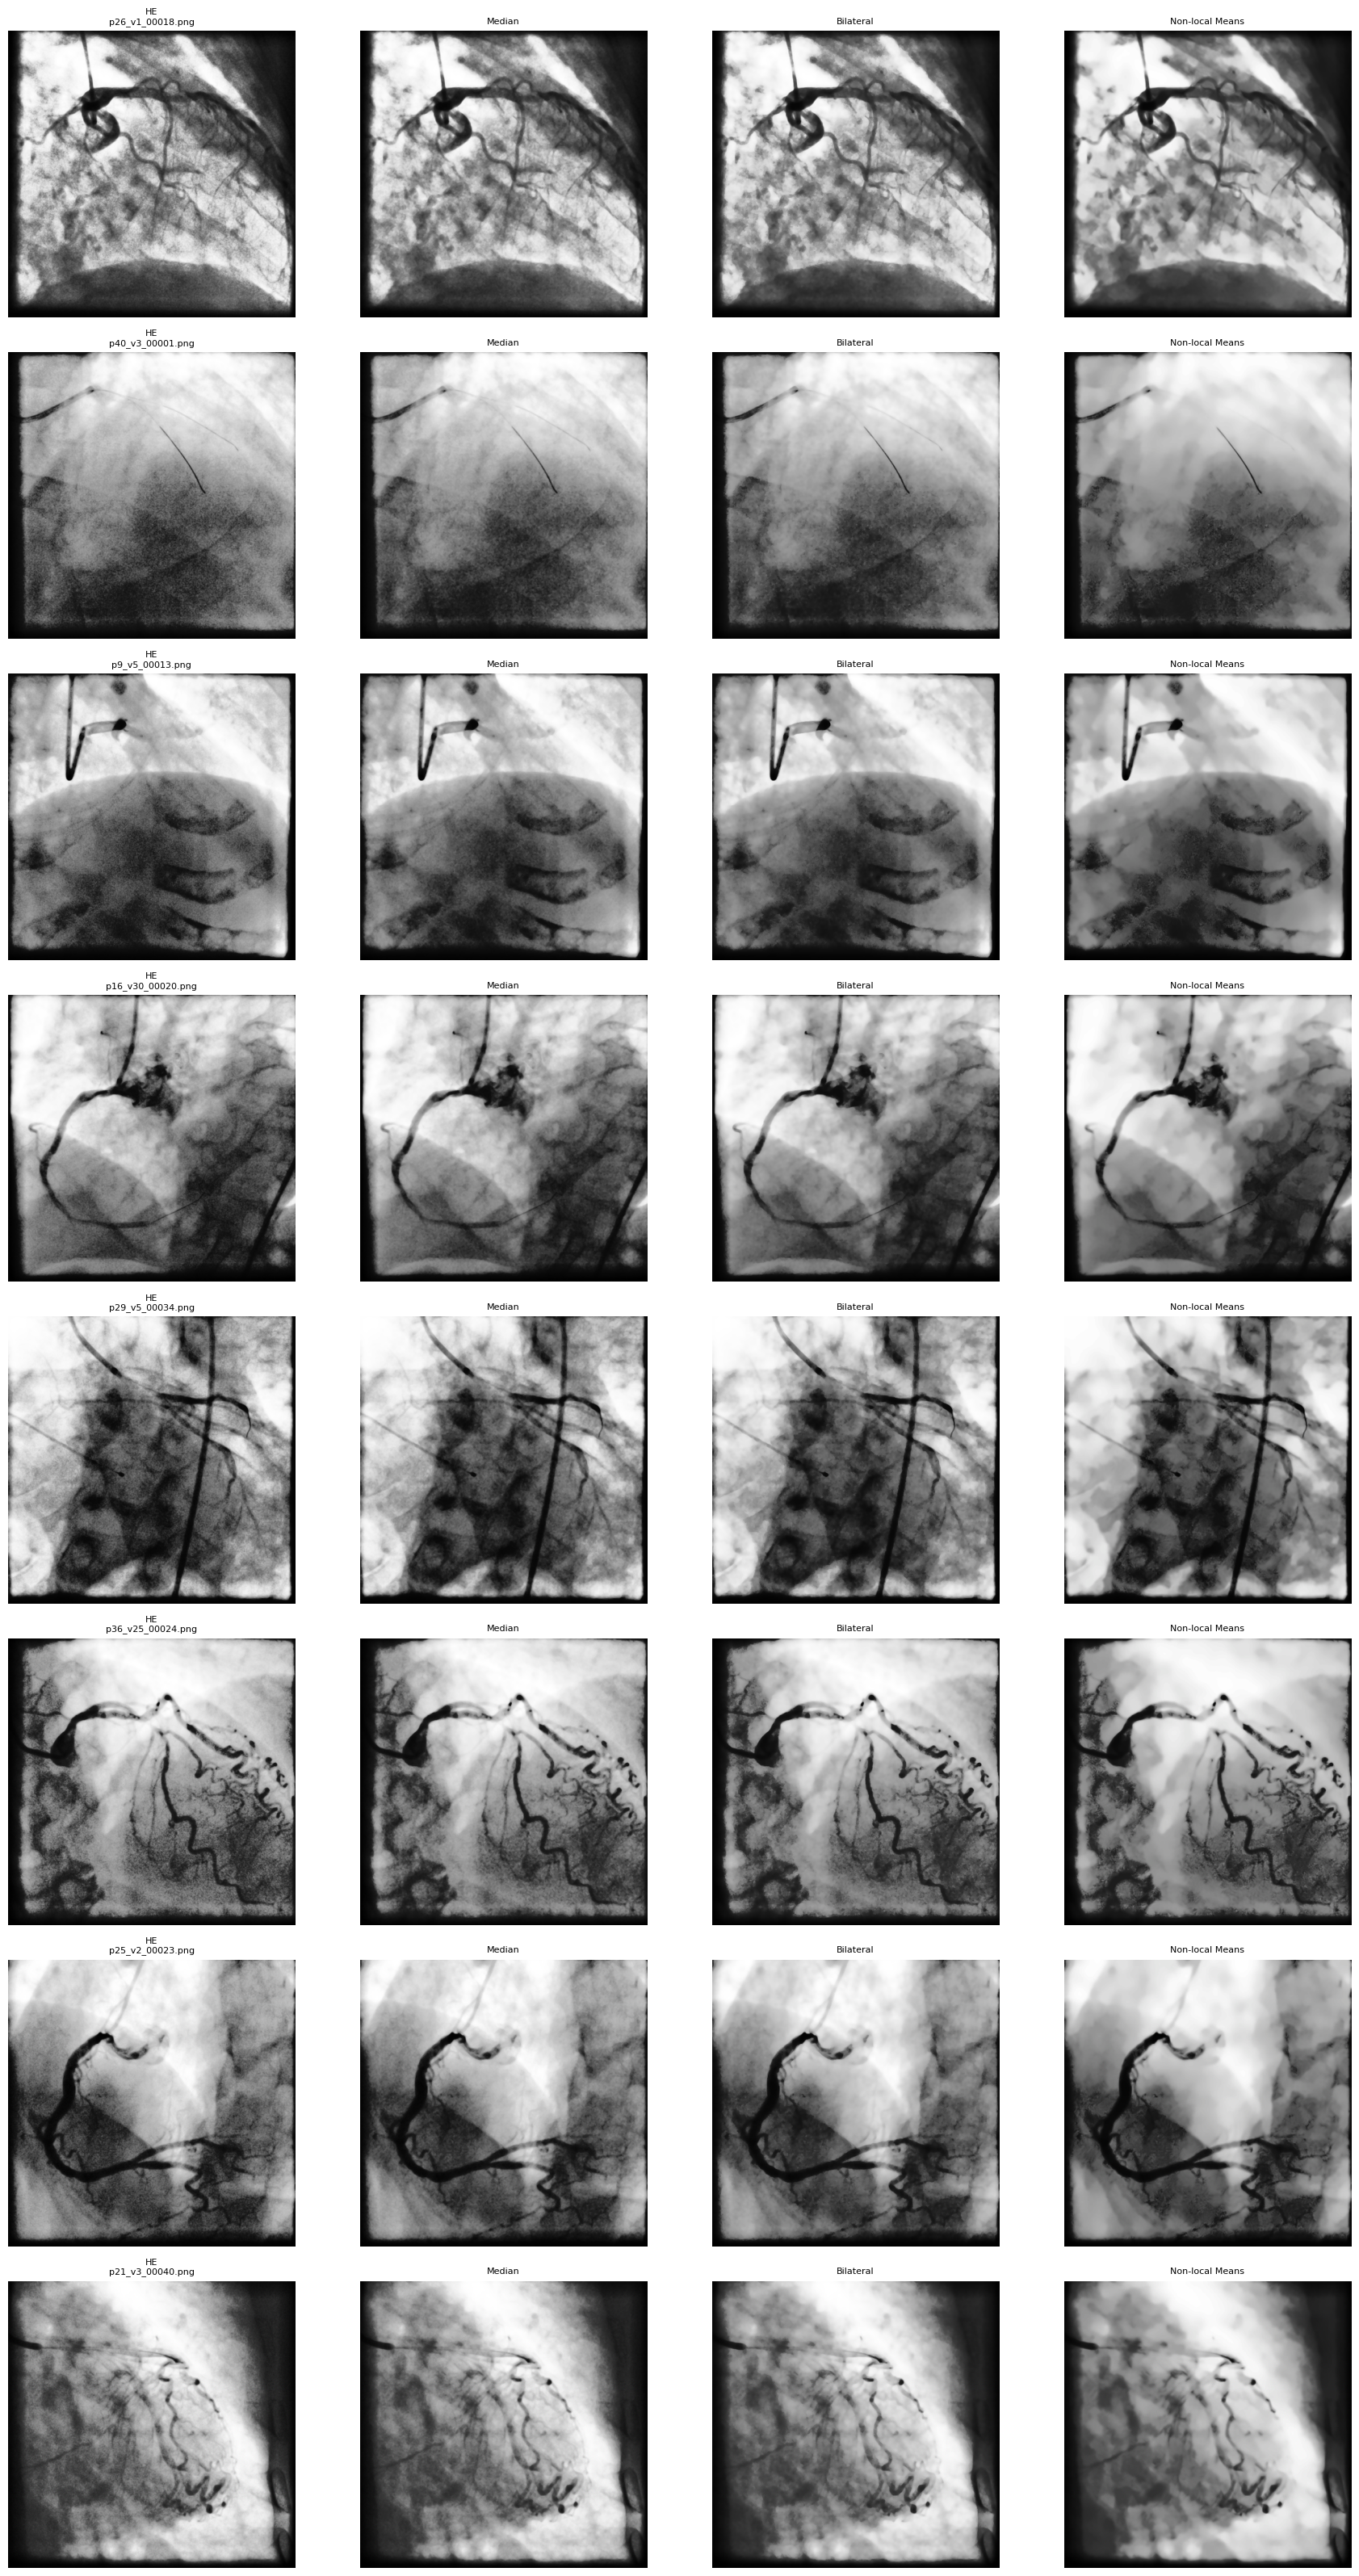

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

HE_DIR = PROJECT_DIR / "11_detection_dataset_ratio2_HE" / "images" / "train"

# 랜덤 이미지 8장
sample_files = random.sample(list(HE_DIR.glob("*.png")), 8)

fig, axes = plt.subplots(len(sample_files), 4, figsize=(18, 4*len(sample_files)))

for i, img_path in enumerate(sample_files):

    he = cv2.imread(str(img_path))

    # Filter
    median = cv2.medianBlur(he, 3)

    bilateral = cv2.bilateralFilter(
        he,
        d=7,
        sigmaColor=40,
        sigmaSpace=40
    )

    nlm = cv2.fastNlMeansDenoisingColored(
        he,
        None,
        h=7,
        hColor=7,
        templateWindowSize=7,
        searchWindowSize=21
    )

    imgs = [he, median, bilateral, nlm]
    imgs = [cv2.cvtColor(x, cv2.COLOR_BGR2RGB) for x in imgs]

    titles = [
        f"HE\n{img_path.name}",
        "Median",
        "Bilateral",
        "Non-local Means"
    ]

    for j in range(4):

        axes[i, j].imshow(imgs[j])
        axes[i, j].set_title(titles[j], fontsize=8)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

# CADICA 프레임 분석

In [ ]:

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

CADICA_DIR = PROJECT_DIR / "CADICA"

print(CADICA_DIR)

/content/drive/MyDrive/DL_project/CADICA


In [ ]:
for item in sorted(CADICA_DIR.iterdir()):
    print(item.name)

metadata.xlsx
nonselectedVideos
readme.txt
selectedVideos


In [ ]:
SELECTED_DIR = CADICA_DIR / "selectedVideos"

patients = sorted([p for p in SELECTED_DIR.iterdir() if p.is_dir()])

print(f"Patient 수 : {len(patients)}")

print("\n처음 10개")
for p in patients[:10]:
    print(p.name)

Patient 수 : 42

처음 10개
p1
p10
p11
p12
p13
p14
p15
p16
p17
p18


In [ ]:
first_patient = patients[0]

print(first_patient)

for item in sorted(first_patient.iterdir()):
    print(item.name)

/content/drive/MyDrive/DL_project/CADICA/selectedVideos/p1
lesionVideos.txt
nonlesionVideos.txt
v1
v10
v11
v12
v13
v14
v2
v3
v4
v5
v6
v9


In [ ]:
first_video = first_patient / "v1"

print(first_video)

for item in sorted(first_video.iterdir()):
    print(item.name)


/content/drive/MyDrive/DL_project/CADICA/selectedVideos/p1/v1
input
p1_v1_selectedFrames.txt


1. 전체 비디오 수 확인
2. 비디오별 프레임 수 통계
3. 프레임 수 분포(histogram)
4. 대표 영상 3개 선정
5. 연속 프레임 시각화
6. SSIM 계산
7. 전체 데이터셋으로 확장
8. 샘플링 간격 결정

In [ ]:
INPUT_DIR = first_video / "input"

frames = sorted(INPUT_DIR.glob("*.png"))

print(f"Frame 수 : {len(frames)}")

print("\n처음 5장")
for f in frames[:5]:
    print(f.name)

print("\n마지막 5장")
for f in frames[-5:]:
    print(f.name)

Frame 수 : 55

처음 5장
p1_v1_00001.png
p1_v1_00002.png
p1_v1_00003.png
p1_v1_00004.png
p1_v1_00005.png

마지막 5장
p1_v1_00051.png
p1_v1_00052.png
p1_v1_00053.png
p1_v1_00054.png
p1_v1_00055.png


In [ ]:
video_infos = []

for patient in tqdm(patients):

    for video in sorted(patient.glob("v*")):

        input_dir = video / "input"

        if not input_dir.exists():
            continue

        n_frames = len(list(input_dir.glob("*.png")))

        video_infos.append({
            "patient": patient.name,
            "video": video.name,
            "frames": n_frames
        })

video_df = pd.DataFrame(video_infos)

video_df.head()

100%|██████████| 42/42 [02:59<00:00,  4.27s/it]


,patient,video,frames
0,p1,v1,55
1,p1,v10,56
2,p1,v11,44
3,p1,v12,49
4,p1,v13,25


In [ ]:
print(f"총 Video 수 : {len(video_df)}")

print(video_df["frames"].describe())

총 Video 수 : 382
count    382.000000
mean      47.523560
std       14.370362
min        1.000000
25%       38.000000
50%       47.000000
75%       55.000000
max      101.000000
Name: frames, dtype: float64


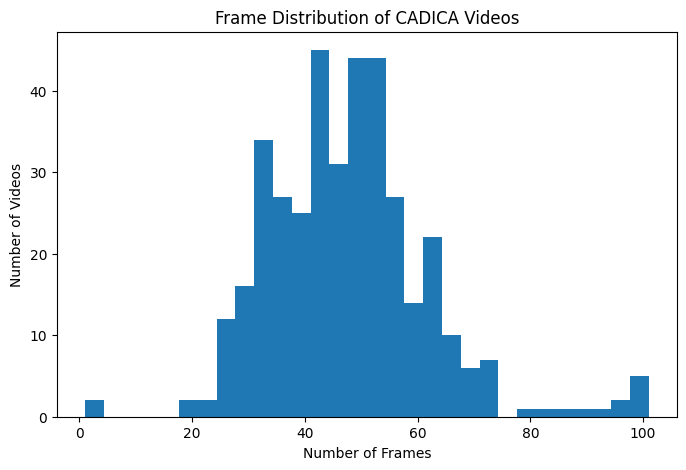

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(video_df["frames"], bins=30)

plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")
plt.title("Frame Distribution of CADICA Videos")

plt.show()

In [ ]:
# lesion, non-lesion 각각 분석

In [ ]:
video_labels = []

for patient in tqdm(patients):

    lesion_txt = patient / "lesionVideos.txt"
    nonlesion_txt = patient / "nonlesionVideos.txt"

    lesion_videos = set()
    nonlesion_videos = set()

    if lesion_txt.exists():
        with open(lesion_txt) as f:
            lesion_videos = {
                line.strip()
                for line in f
                if line.strip()
            }

    if nonlesion_txt.exists():
        with open(nonlesion_txt) as f:
            nonlesion_videos = {
                line.strip()
                for line in f
                if line.strip()
            }

    for video in lesion_videos:
        video_labels.append({
            "patient": patient.name,
            "video": video,
            "label": "lesion"
        })

    for video in nonlesion_videos:
        video_labels.append({
            "patient": patient.name,
            "video": video,
            "label": "non-lesion"
        })

label_df = pd.DataFrame(video_labels)

label_df.head()

100%|██████████| 42/42 [00:44<00:00,  1.05s/it]


,patient,video,label
0,p1,v2,lesion
1,p1,v3,lesion
2,p1,v11,lesion
3,p1,v10,lesion
4,p1,v14,non-lesion


In [ ]:
video_df = video_df.merge(
    label_df,
    on=["patient", "video"],
    how="left"
)

video_df.head()

,patient,video,frames,label
0,p1,v1,55,non-lesion
1,p1,v10,56,lesion
2,p1,v11,44,lesion
3,p1,v12,49,non-lesion
4,p1,v13,25,non-lesion


In [ ]:
video_df.groupby("label")["frames"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
lesion,269.0,48.327138,15.142755,1.0,38.0,48.0,56.0,101.0
non-lesion,113.0,45.610619,12.188573,25.0,37.0,44.0,52.0,101.0


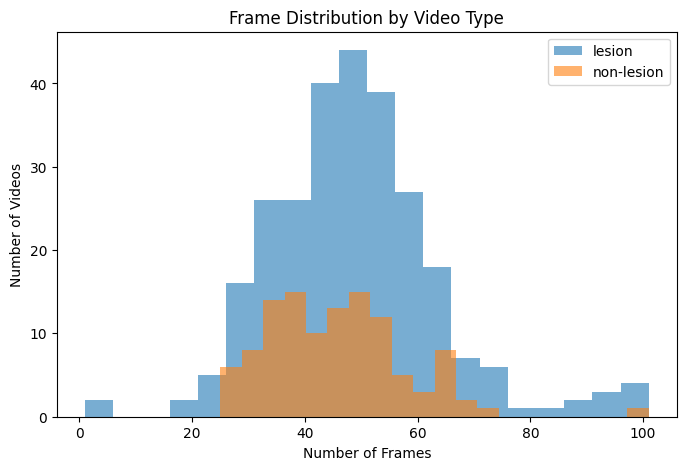

In [ ]:
plt.figure(figsize=(8,5))

for label in ["lesion", "non-lesion"]:

    subset = video_df[video_df["label"] == label]

    plt.hist(
        subset["frames"],
        bins=20,
        alpha=0.6,
        label=label
    )

plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")
plt.title("Frame Distribution by Video Type")

plt.legend()

plt.show()

In [ ]:
from pathlib import Path
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim


def analyze_video_redundancy(input_dir: Path,
                             gaps=[1, 2, 3, 5, 10]):

    frame_paths = sorted(input_dir.glob("*.png"))

    if len(frame_paths) < 2:
        return None

    # 이미지를 한 번만 읽기
    frames = [
        cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        for f in frame_paths
    ]

    results = {}

    for gap in gaps:

        if len(frames) <= gap:
            continue

        ssim_scores = []

        for i in range(len(frames) - gap):

            score = ssim(
                frames[i],
                frames[i + gap]
            )

            ssim_scores.append(score)

        results[f"gap{gap}_mean_ssim"] = np.mean(ssim_scores)
        results[f"gap{gap}_std_ssim"] = np.std(ssim_scores)

    return results

In [ ]:
import pandas as pd
import numpy as np

# 재현 가능하도록 고정
np.random.seed(42)

sample_list = []

for label in ["lesion", "non-lesion"]:

    subset = video_df[video_df["label"] == label].copy()

    # frame 수 기준으로 3등분
    subset["frame_group"] = pd.qcut(
        subset["frames"],
        q=3,
        labels=["short", "medium", "long"],
        duplicates="drop"
    )

    for group in subset["frame_group"].unique():

        group_df = subset[subset["frame_group"] == group]

        # 각 그룹에서 10개씩
        n = min(10, len(group_df))

        sample_list.append(
            group_df.sample(n=n, random_state=42)
        )

sample_df = pd.concat(sample_list).reset_index(drop=True)

print(f"Selected Videos : {len(sample_df)}")
sample_df.head()

Selected Videos : 60


,patient,video,frames,label,frame_group
0,p41,v5,65,lesion,long
1,p1,v10,56,lesion,long
2,p18,v4,60,lesion,long
3,p17,v19,57,lesion,long
4,p15,v1,93,lesion,long


In [ ]:
sample_df.groupby(
    ["label", "frame_group"]
).size()

/tmp/ipykernel_535/1447441058.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_df.groupby(


label       frame_group
lesion      short          10
            medium         10
            long           10
non-lesion  short          10
            medium         10
            long           10
dtype: int64

In [ ]:
from tqdm import tqdm

redundancy_results = []

for _, row in tqdm(sample_df.iterrows(),
                   total=len(sample_df),
                   desc="Analyzing Sample Videos"):

    input_dir = (
        SELECTED_DIR
        / row["patient"]
        / row["video"]
        / "input"
    )

    result = analyze_video_redundancy(input_dir)

    if result is None:
        continue

    result["patient"] = row["patient"]
    result["video"] = row["video"]
    result["label"] = row["label"]
    result["frames"] = row["frames"]
    result["frame_group"] = row["frame_group"]

    redundancy_results.append(result)

redundancy_df = pd.DataFrame(redundancy_results)

print(redundancy_df.shape)

redundancy_df.head()

Analyzing Sample Videos: 100%|██████████| 60/60 [36:33<00:00, 36.56s/it]

(60, 15)


,gap1_mean_ssim,gap1_std_ssim,gap2_mean_ssim,gap2_std_ssim,gap3_mean_ssim,gap3_std_ssim,gap5_mean_ssim,gap5_std_ssim,gap10_mean_ssim,gap10_std_ssim,patient,video,label,frames,frame_group
0,0.901002,0.022635,0.886541,0.023549,0.878938,0.023585,0.875877,0.024302,0.866092,0.022299,p41,v5,lesion,65,long
1,0.802148,0.046700,0.764789,0.043505,0.747249,0.037460,0.730983,0.030279,0.720326,0.019533,p1,v10,lesion,56,long
2,0.894869,0.025580,0.874637,0.025603,0.866178,0.025524,0.859646,0.024705,0.855984,0.020636,p18,v4,lesion,60,long
3,0.922507,0.013004,0.915371,0.013522,0.912043,0.013994,0.909082,0.012389,0.905958,0.009835,p17,v19,lesion,57,long
4,0.785920,0.039455,0.756842,0.043461,0.741387,0.043806,0.723658,0.043660,0.704367,0.042605,p15,v1,lesion,93,long


In [ ]:
summary = redundancy_df[
    [
        "gap1_mean_ssim",
        "gap2_mean_ssim",
        "gap3_mean_ssim",
        "gap5_mean_ssim",
        "gap10_mean_ssim",
    ]
].agg(["mean", "std"])

summary

,gap1_mean_ssim,gap2_mean_ssim,gap3_mean_ssim,gap5_mean_ssim,gap10_mean_ssim
mean,0.851341,0.829083,0.818409,0.808057,0.794097
std,0.071749,0.079294,0.082838,0.087309,0.094105


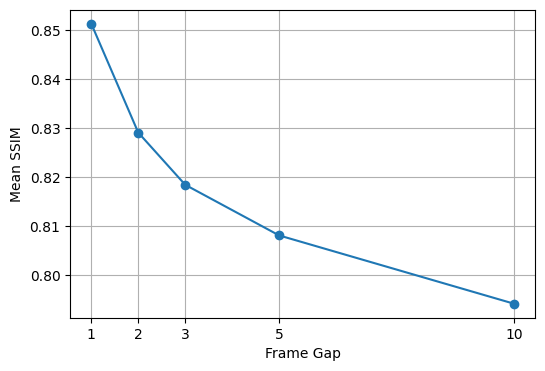

In [ ]:
import matplotlib.pyplot as plt

gap_means = [
    redundancy_df["gap1_mean_ssim"].mean(),
    redundancy_df["gap2_mean_ssim"].mean(),
    redundancy_df["gap3_mean_ssim"].mean(),
    redundancy_df["gap5_mean_ssim"].mean(),
    redundancy_df["gap10_mean_ssim"].mean(),
]

gaps = [1, 2, 3, 5, 10]

plt.figure(figsize=(6,4))
plt.plot(gaps, gap_means, marker="o")
plt.xticks(gaps)
plt.xlabel("Frame Gap")
plt.ylabel("Mean SSIM")
plt.grid(True)
plt.show()

In [ ]:
redundancy_df.groupby("label")[
    [
        "gap1_mean_ssim",
        "gap2_mean_ssim",
        "gap3_mean_ssim",
        "gap5_mean_ssim",
        "gap10_mean_ssim",
    ]
].mean()

,gap1_mean_ssim,gap2_mean_ssim,gap3_mean_ssim,gap5_mean_ssim,gap10_mean_ssim
label,,,,,
lesion,0.848954,0.826894,0.815872,0.804519,0.791051
non-lesion,0.853727,0.831272,0.820945,0.811595,0.797143


In [ ]:
# GAP 3 결정

# 프레임 분석 결과 GAP 3으로 설정해서 데이터셋 새로 생성

Section 1
Output 경로 설정

↓

Section 2
Gap=3 Frame Sampling

↓

Section 3
Bounding Box 변환

↓

Section 4
Train / Val / Test 생성

↓

Section 5
Background 1:2 적용

↓

Section 6
dataset.yaml 생성

↓

Section 7
Dataset 통계 확인

In [ ]:
OUTPUT_DIR = PROJECT_DIR / "09_detection_dataset_gap3"

In [ ]:
###################

In [ ]:
!pip install ultralytics

import os
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import shutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.3 MB/s eta 0:00:00


In [ ]:
from PIL import Image

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

CADICA_DIR = PROJECT_DIR / "CADICA"

CSV_PATH = PROJECT_DIR / "common_split.csv"

# 변경
OUTPUT_DIR = PROJECT_DIR / "09_detection_dataset_gap3"

OUTPUT_DIR.mkdir(exist_ok=True)

print(PROJECT_DIR)
print(CADICA_DIR)
print(CSV_PATH)
print(OUTPUT_DIR)

/content/drive/MyDrive/DL_project
/content/drive/MyDrive/DL_project/CADICA
/content/drive/MyDrive/DL_project/common_split.csv
/content/drive/MyDrive/DL_project/09_detection_dataset_gap3


In [ ]:
df = pd.read_csv(CSV_PATH)

print(df.head())
print(df.info())

  patient_id video_id       label view  n_frames  has_groundtruth  split
0         p1       v2      lesion  LCA        56             True  train
1         p1       v3      lesion  LCA        44             True  train
2         p1      v10      lesion  LCA        56             True  train
3         p1      v11      lesion  LCA        44             True  train
4         p1       v1  non-lesion  LCA        55            False  train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   patient_id       334 non-null    object
 1   video_id         334 non-null    object
 2   label            334 non-null    object
 3   view             334 non-null    object
 4   n_frames         334 non-null    int64 
 5   has_groundtruth  334 non-null    bool  
 6   split            334 non-null    object
dtypes: bool(1), int64(1), object(5)
memory usage: 16

In [ ]:
IMAGE_DIR = OUTPUT_DIR / "images"
LABEL_DIR = OUTPUT_DIR / "labels"

for split in ["train", "val", "test"]:
    (IMAGE_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABEL_DIR / split).mkdir(parents=True, exist_ok=True)

In [ ]:
def convert_bbox_to_yolo(x, y, w, h, img_width, img_height):

    x_center = x + (w / 2)
    y_center = y + (h / 2)

    x_center /= img_width
    y_center /= img_height
    w /= img_width
    h /= img_height

    return x_center, y_center, w, h

In [ ]:
def build_gt_index(gt_dir):

    gt_index = set()

    for txt_file in gt_dir.glob("*.txt"):
        gt_index.add(txt_file.stem)

    return gt_index

In [ ]:
# ==========================================================
# Video 하나 처리
# ==========================================================

FRAME_GAP = 3   # ← 추가

def process_video(row):

    # ----------------------------------------
    # 1. CSV 정보
    # ----------------------------------------
    patient_id = row["patient_id"]
    video_id = row["video_id"]
    split = row["split"]

    # ----------------------------------------
    # 2. input / groundtruth 경로
    # ----------------------------------------
    input_dir = (
        CADICA_DIR /
        "selectedVideos" /
        patient_id /
        video_id /
        "input"
    )

    gt_dir = (
        CADICA_DIR /
        "selectedVideos" /
        patient_id /
        video_id /
        "groundtruth"
    )

    # ----------------------------------------
    # 3. 이미지 목록 (Gap 적용)
    # ----------------------------------------
    image_files = sorted(input_dir.glob("*.png"))
    image_files = image_files[::FRAME_GAP]

    # ----------------------------------------
    # 4. Ground Truth 목록
    # ----------------------------------------
    if gt_dir.exists():
        gt_index = build_gt_index(gt_dir)
    else:
        gt_index = set()

    # ----------------------------------------
    # 5. 모든 이미지 처리
    # ----------------------------------------
    for image_file in image_files:

        image_name = image_file.stem

        save_image = IMAGE_DIR / split / image_file.name
        save_label = LABEL_DIR / split / f"{image_name}.txt"

        shutil.copy(image_file, save_image)

        if image_name in gt_index:

            annotation_file = gt_dir / f"{image_name}.txt"

            img = Image.open(image_file)
            img_width, img_height = img.size

            with open(annotation_file, "r") as f_in, open(save_label, "w") as f_out:

                for line in f_in:

                    x, y, w, h, lesion_id = line.strip().split()

                    x = int(x)
                    y = int(y)
                    w = int(w)
                    h = int(h)

                    x_center, y_center, width, height = convert_bbox_to_yolo(
                        x, y, w, h,
                        img_width, img_height
                    )

                    f_out.write(
                        f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
                    )

        else:
            open(save_label, "w").close()

In [ ]:
def build_detection_dataset(df):

    for _, row in tqdm(df.iterrows(), total=len(df)):
        process_video(row)

    print("detection dataset 생성 완료")

In [ ]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

IMAGE_DIR = OUTPUT_DIR / "images"
LABEL_DIR = OUTPUT_DIR / "labels"

for split in ["train", "val", "test"]:
    (IMAGE_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABEL_DIR / split).mkdir(parents=True, exist_ok=True)

print("기존 테스트 데이터 삭제 완료")

기존 테스트 데이터 삭제 완료


In [ ]:
build_detection_dataset(df)

100%|██████████| 334/334 [1:14:41<00:00, 13.42s/it]

detection dataset 생성 완료


In [ ]:
for split in ["train", "val", "test"]:

    image_count = len(list((IMAGE_DIR / split).glob("*.png")))
    label_count = len(list((LABEL_DIR / split).glob("*.txt")))

    print(split)
    print("Images :", image_count)
    print("Labels :", label_count)
    print("-"*30)

train
Images : 4531
Labels : 4531
------------------------------
val
Images : 478
Labels : 478
------------------------------
test
Images : 371
Labels : 371
------------------------------


In [ ]:
yaml_text = f"""
path: {OUTPUT_DIR}

train: images/train
val: images/val
test: images/test

names:
  0: lesion
"""

yaml_path = OUTPUT_DIR / "dataset.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print(yaml_path)

/content/drive/MyDrive/DL_project/09_detection_dataset_gap3/dataset.yaml


In [ ]:
from ultralytics import YOLO

BEST_WEIGHT = PROJECT_DIR / "weights" / "ADSD640_best.pt"

CADICA_DIR = PROJECT_DIR / "09_detection_dataset_gap3"

model = YOLO(str(BEST_WEIGHT))

EPOCHS = 50
IMGSZ = 640
BATCH = 16

DEVICE = 0
WORKERS = 4
PATIENCE = 20

PROJECT = str(PROJECT_DIR / "runs")
NAME = "YOLO11_CADICA_gap3"

print("=" * 60)
print("Step 14. Gap3 Fine-tuning")
print("=" * 60)
print(f"Pretrained Weight : {BEST_WEIGHT}")
print(f"Dataset           : {CADICA_DIR}")
print(f"Epochs            : {EPOCHS}")
print(f"Image Size        : {IMGSZ}")
print(f"Batch Size        : {BATCH}")
print(f"Save Name         : {NAME}")

Step 14. Gap3 Fine-tuning
Pretrained Weight : /content/drive/MyDrive/DL_project/weights/ADSD640_best.pt
Dataset           : /content/drive/MyDrive/DL_project/09_detection_dataset_gap3
Epochs            : 50
Image Size        : 640
Batch Size        : 16
Save Name         : YOLO11_CADICA_gap3


In [ ]:
results = model.train(

    data=str(CADICA_DIR / "dataset.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    patience=PATIENCE,

    project=PROJECT,
    name=NAME,

    exist_ok=True,
    pretrained=True,
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.4.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/09_detection_dataset_gap3/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/c

In [ ]:
best_model = YOLO(
    str(PROJECT_DIR / "runs" / "YOLO11_CADICA_gap3" / "weights" / "best.pt")
)

print("Best Model Load 완료")

Best Model Load 완료


In [ ]:
metrics = best_model.val(
    data=str(yaml_path)
)

print(metrics)

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 0.1±0.0 MB/s, size: 102.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/DL_project/09_detection_dataset_gap3/labels/val.cache... 478 images, 363 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 478/478 50.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 6.3it/s 4.8s
                   all        478        173      0.165      0.156     0.0908     0.0313
Speed: 1.0ms preprocess, 4.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: arr

In [ ]:
# best_model.predict(
#     source=str(PROJECT_DIR / "09_detection_dataset_gap3" / "images" / "test"),
#     save=True,
#     conf=0.25
# )

## gap3 + 1:2 background douwnsampling

In [ ]:
import shutil
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

SRC_DIR = PROJECT_DIR / "09_detection_dataset_gap3"
DST_DIR = PROJECT_DIR / "09_detection_dataset_gap3_ratio2"

if DST_DIR.exists():
    shutil.rmtree(DST_DIR)

shutil.copytree(SRC_DIR, DST_DIR)

print("Dataset copied!")

Dataset copied!


In [ ]:
import random
import os
from pathlib import Path

random.seed(42)

train_img_dir = DST_DIR / "images" / "train"
train_lbl_dir = DST_DIR / "labels" / "train"

positive = []
background = []

for label_file in train_lbl_dir.glob("*.txt"):

    img_file = train_img_dir / (label_file.stem + ".png")

    if os.path.getsize(label_file) == 0:
        background.append((img_file, label_file))
    else:
        positive.append((img_file, label_file))

print(f"Positive   : {len(positive)}")
print(f"Background : {len(background)}")

target_background = min(len(background), len(positive) * 2)

keep_background = set(random.sample(background, target_background))

remove_background = set(background) - keep_background

for img_file, label_file in remove_background:

    if img_file.exists():
        img_file.unlink()

    if label_file.exists():
        label_file.unlink()

print("\nBackground Downsampling Complete!")
print(f"Remaining Positive   : {len(positive)}")
print(f"Remaining Background : {target_background}")
print(f"Ratio ≈ 1 : {target_background/len(positive):.2f}")

Positive   : 1045
Background : 3486

Background Downsampling Complete!
Remaining Positive   : 1045
Remaining Background : 2090
Ratio ≈ 1 : 2.00


In [ ]:
from pathlib import Path
import os

train_img_dir = DST_DIR / "images" / "train"
train_lbl_dir = DST_DIR / "labels" / "train"

positive = 0
background = 0

for f in train_lbl_dir.glob("*.txt"):
    if os.path.getsize(f) == 0:
        background += 1
    else:
        positive += 1

print("="*40)
print("Dataset Summary")
print("="*40)

print(f"Positive   : {positive}")
print(f"Background : {background}")

print(f"Ratio      : 1 : {background/positive:.2f}")

print()

print(f"Train Images : {len(list(train_img_dir.glob('*')))}")
print(f"Train Labels : {len(list(train_lbl_dir.glob('*.txt')))}")

Dataset Summary
Positive   : 1045
Background : 2090
Ratio      : 1 : 2.00

Train Images : 3135
Train Labels : 3135


In [ ]:
from pathlib import Path

yaml_path = PROJECT_DIR / "09_detection_dataset_gap3_ratio2" / "dataset.yaml"
print(yaml_path.exists())

True


In [ ]:
from pathlib import Path

CADICA_DIR = PROJECT_DIR / "09_detection_dataset_gap3_ratio2"

print(CADICA_DIR)
print((CADICA_DIR / "dataset.yaml").exists())

train_imgs = len(list((CADICA_DIR / "images/train").glob("*.png")))
print(train_imgs)

/content/drive/MyDrive/DL_project/09_detection_dataset_gap3_ratio2
True
3135


In [ ]:
from pathlib import Path

CADICA_DIR = PROJECT_DIR / "09_detection_dataset_gap3_ratio2"

print("Dataset :", CADICA_DIR)
print("yaml :", (CADICA_DIR / "dataset.yaml").exists())

train_images = len(list((CADICA_DIR / "images/train").glob("*.png")))
train_labels = len(list((CADICA_DIR / "labels/train").glob("*.txt")))

print("Train Images :", train_images)
print("Train Labels :", train_labels)

Dataset : /content/drive/MyDrive/DL_project/09_detection_dataset_gap3_ratio2
yaml : True
Train Images : 3135
Train Labels : 3135


In [ ]:
from ultralytics import YOLO

BEST_WEIGHT = PROJECT_DIR / "weights" / "ADSD640_best.pt"

CADICA_DIR = PROJECT_DIR / "09_detection_dataset_gap3_ratio2"

model = YOLO(str(BEST_WEIGHT))

EPOCHS = 50
IMGSZ = 640
BATCH = 16

DEVICE = 0
WORKERS = 4
PATIENCE = 20

PROJECT = str(PROJECT_DIR / "runs")

#
NAME = "YOLO11_CADICA_gap3_ratio2"

print("=" * 60)
print("Step 14. Gap3 Ratio2 Fine-tuning")
print("=" * 60)
print(f"Pretrained Weight : {BEST_WEIGHT}")
print(f"Dataset           : {CADICA_DIR}")
print(f"Epochs            : {EPOCHS}")
print(f"Image Size        : {IMGSZ}")
print(f"Batch Size        : {BATCH}")
print(f"Save Name         : {NAME}")



Step 14. Gap3 Ratio2 Fine-tuning
Pretrained Weight : /content/drive/MyDrive/DL_project/weights/ADSD640_best.pt
Dataset           : /content/drive/MyDrive/DL_project/09_detection_dataset_gap3_ratio2
Epochs            : 50
Image Size        : 640
Batch Size        : 16
Save Name         : YOLO11_CADICA_gap3_ratio2


In [ ]:
results = model.train(

    data=str(CADICA_DIR / "dataset.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    device=DEVICE,
    workers=WORKERS,

    patience=PATIENCE,

    project=PROJECT,
    name=NAME,

    exist_ok=True,
    pretrained=True,
    verbose=True,
)

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/09_detection_dataset_gap3_ratio2/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DL_project/weights/ADSD640_best.pt, momentum=0.937, mosaic=1.0, multi_sca

In [ ]:
!pip install -U ultralytics
from pathlib import Path
from ultralytics import YOLO


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")

BEST_WEIGHT = PROJECT_DIR / "weights" / "ADSD640_best.pt"

CADICA_DIR = PROJECT_DIR / "09_detection_dataset_gap3"

PROJECT = str(PROJECT_DIR / "runs")

In [ ]:
print(BEST_WEIGHT.exists())
print((CADICA_DIR / "dataset.yaml").exists())

train_images = len(list((CADICA_DIR / "images/train").glob("*.png")))
print(train_images)

True
True
4531


In [ ]:
#############################1.3에서 튜닝

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/DL_project")


BEST_WEIGHT = PROJECT_DIR / "runs" / "YOLO11_CADICA_ratio2" / "weights" / "best.pt"

# 데이터셋
DATASET_DIR = PROJECT_DIR / "10_detection_dataset_ratio2"

PROJECT = str(PROJECT_DIR / "runs")

NAME = "YOLO11_ratio2_tuned"

In [ ]:
print(BEST_WEIGHT.exists())
print((DATASET_DIR / "dataset.yaml").exists())

True
True


In [ ]:
model = YOLO(str(BEST_WEIGHT))

In [ ]:
# =========================
# Training Configuration
# =========================
EPOCHS = 50
IMGSZ = 640

BATCH = 8          # 변경
LR0 = 0.005        # 변경
MOSAIC = 0.5       # 변경

DEVICE = 0
WORKERS = 4
PATIENCE = 20

In [ ]:
results = model.train(
    data=str(DATASET_DIR / "dataset.yaml"),

    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    lr0=LR0,
    mosaic=MOSAIC,

    device=DEVICE,
    workers=WORKERS,
    patience=PATIENCE,

    project=PROJECT,
    name=NAME,
    exist_ok=True,

    pretrained=False,
    verbose=True,
)

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL_project/10_detection_dataset_ratio2/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DL_project/runs/YOLO11_CADICA_ratio2/weights/best.pt, momentum=0.937, mosaic=